<a href="https://colab.research.google.com/github/Shuvo1523004/Machine-Learning/blob/main/3D_printed_full_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported successfully.
Dataset loaded: 179 rows × 13 columns

Features : ['Static Yield Stress (Pa)', 'Dynamic Yield Stress (Pa)', 'Plastic Viscosity (Pa·s)']
Classes  : ['Bauxite tailings', 'Bentonite', 'Metakaolin', 'Nano-kaolin clay', 'SAPs', 'SP+R+A']

Class distribution (n per class):
  Bauxite tailings    : 30
  Bentonite           : 30
  Metakaolin          : 30
  Nano-kaolin clay    : 30
  SAPs                : 30
  SP+R+A              : 29

SECTION 2 — EXPLORATORY DATA ANALYSIS

── 2A. Overall Descriptive Statistics (n=180) ──
       Static_Yield_Stress_Pa  Dynamic_Yield_Stress_Pa  Plastic_Viscosity_Pa_s
count                 179.000                  179.000                 179.000
mean                  548.028                  242.857                   1.294
std                   301.400                  230.086                   1.865
min                   104.000                    8.000                   0.003
25%                   337.995                   5

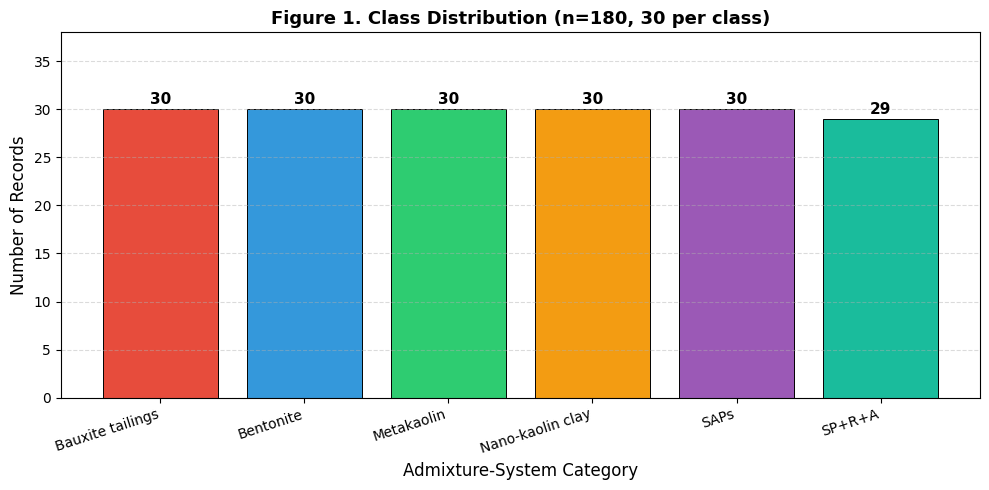

Saved: fig01_class_distribution.png


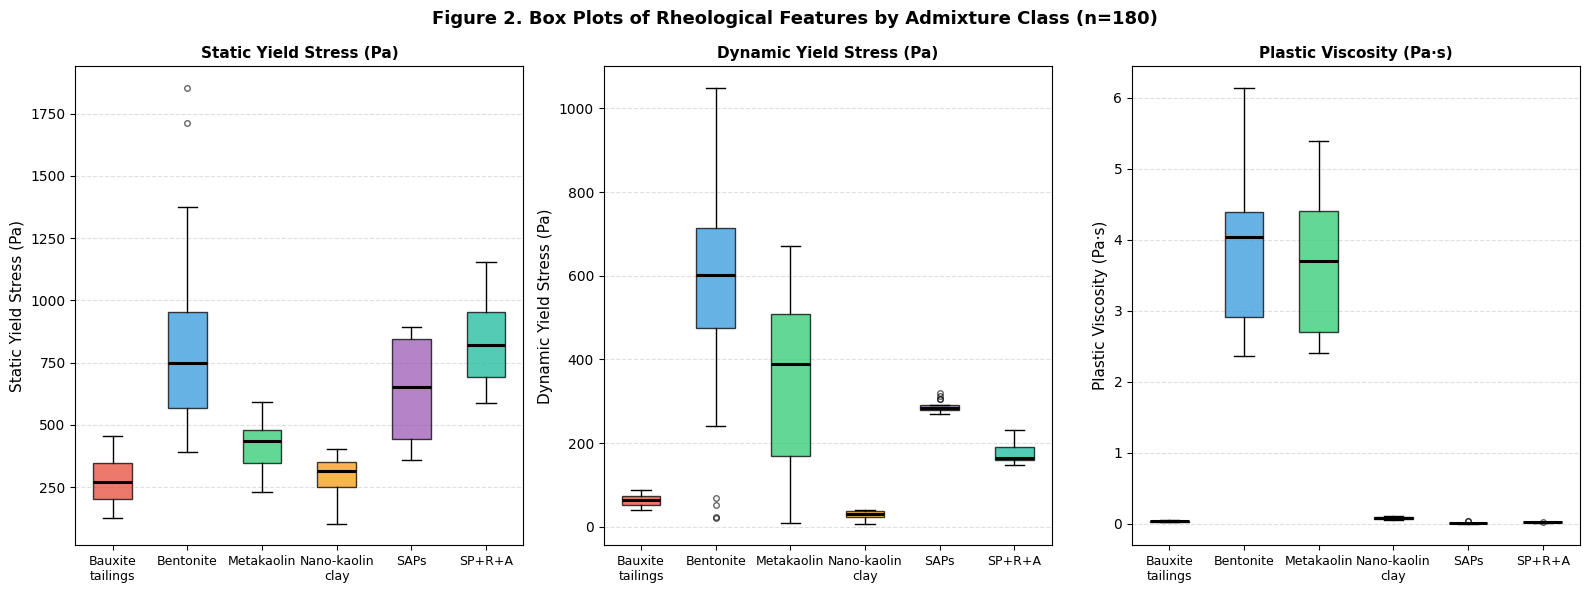

Saved: fig02_boxplots.png


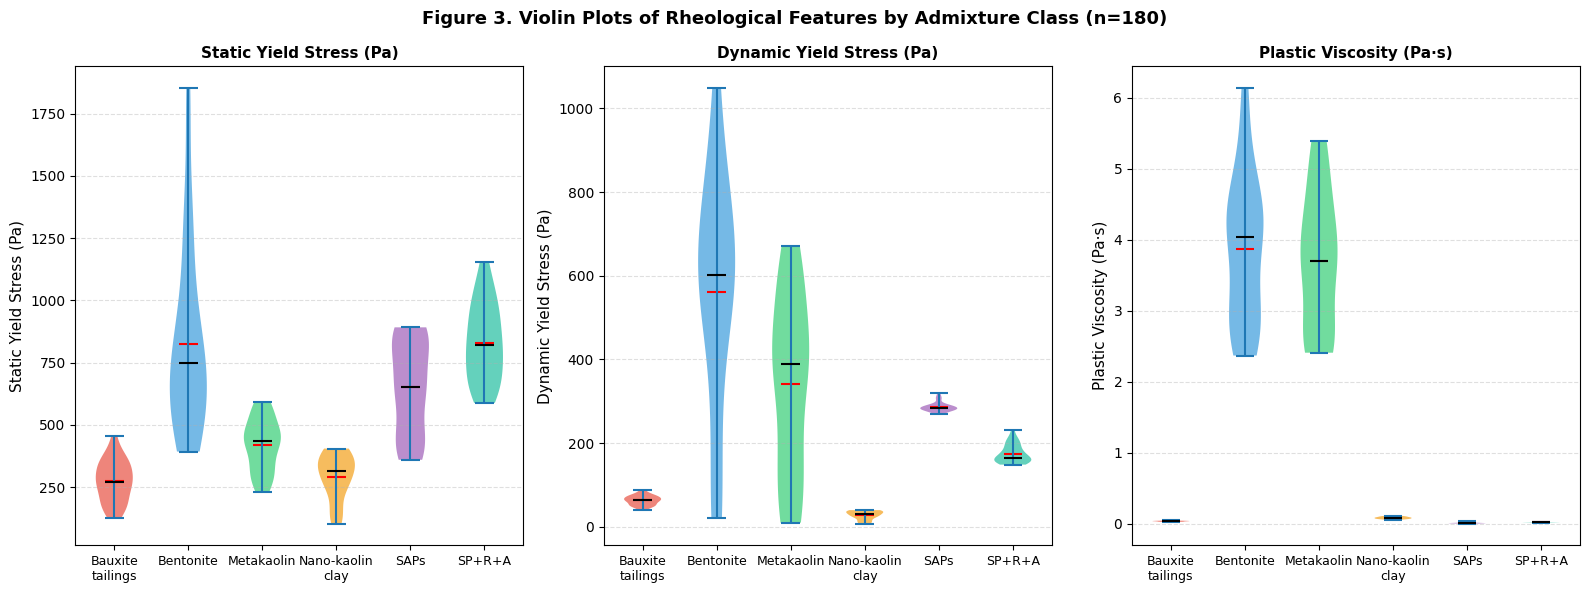

Saved: fig03_violins.png


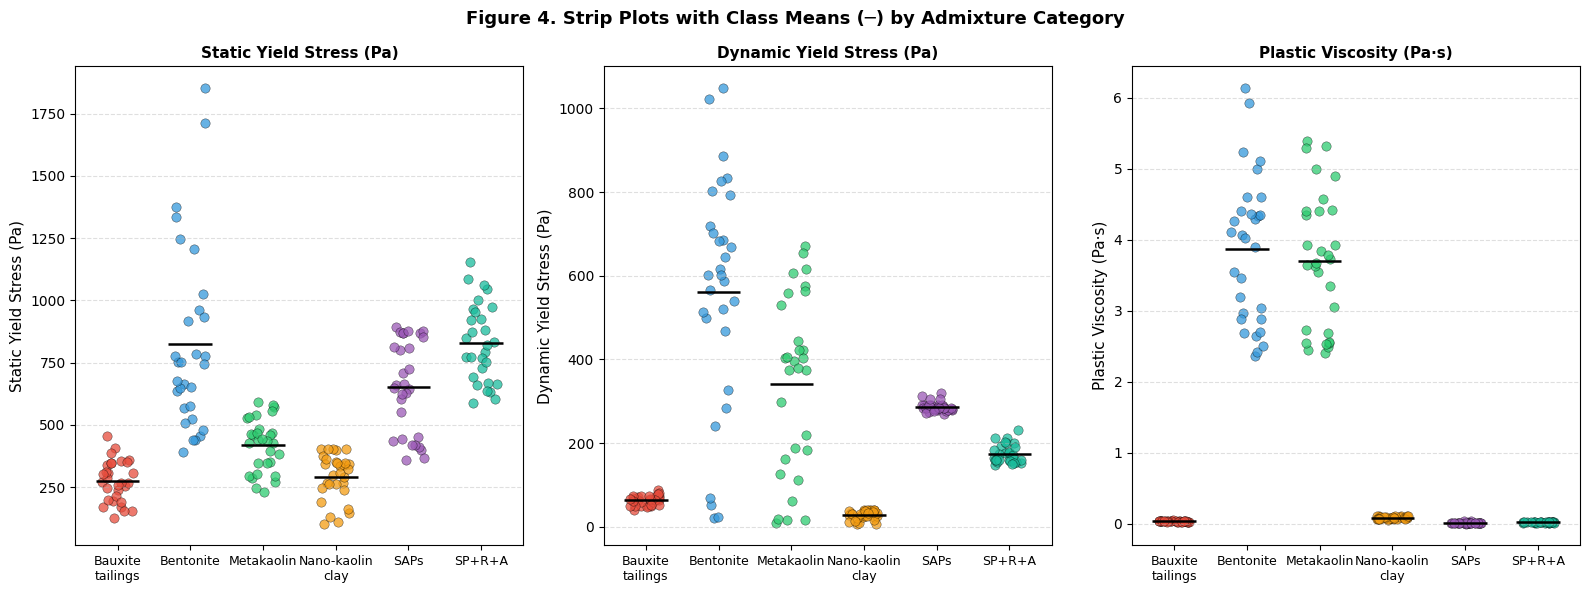

Saved: fig04_stripplots.png


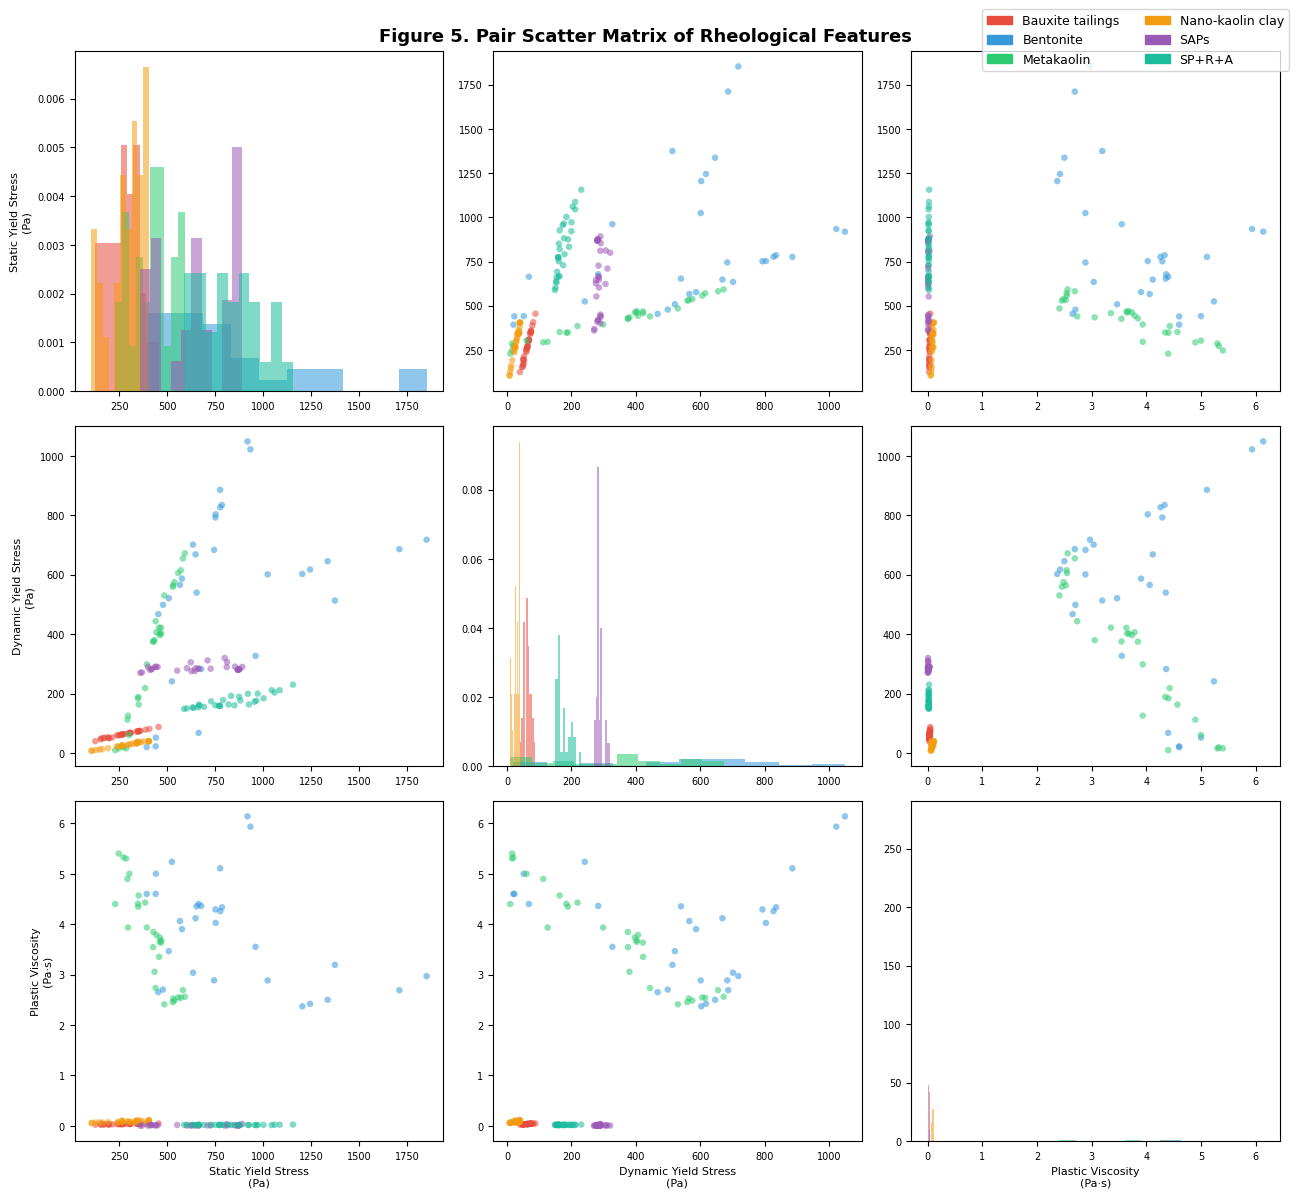

Saved: fig05_pairscatter.png


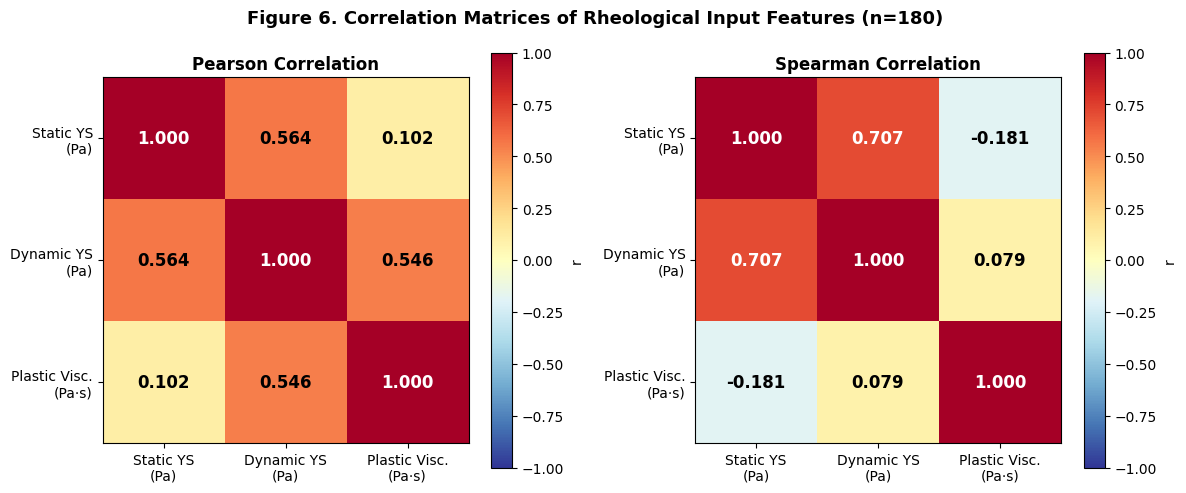

Saved: fig06_correlations.png


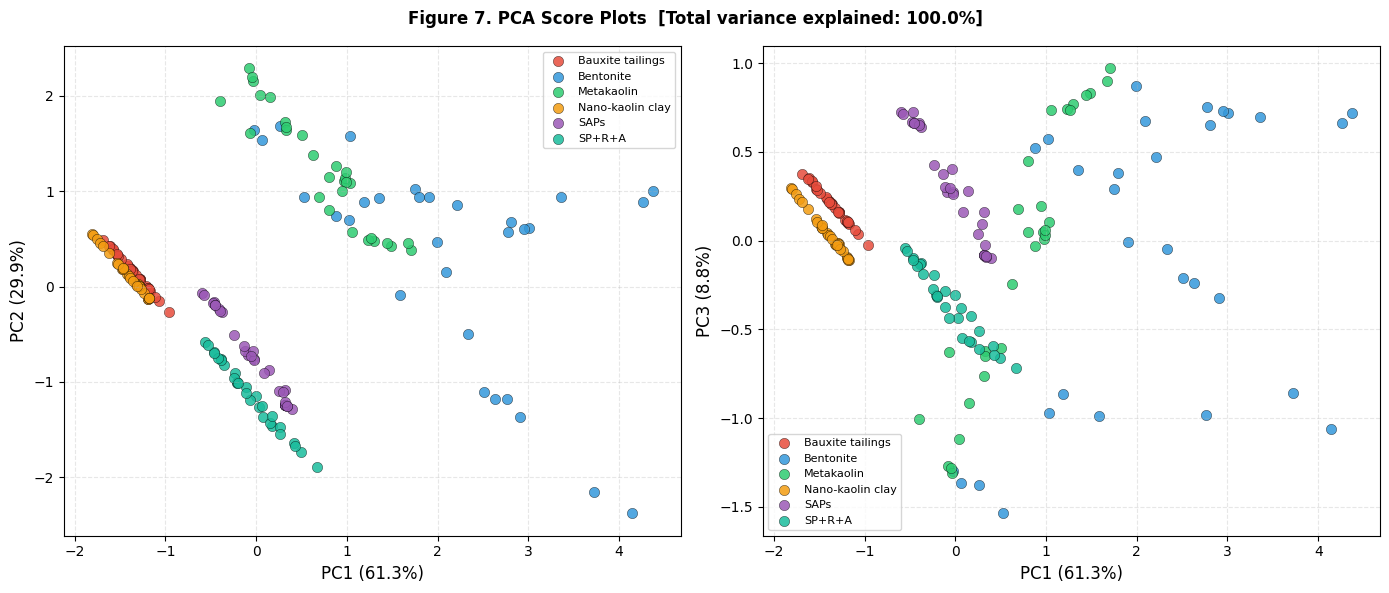


PCA Explained Variance:
  PC1: 61.25%  (cumulative: 61.25%)
  PC2: 29.94%  (cumulative: 91.19%)
  PC3: 8.81%  (cumulative: 100.00%)

PCA Loadings:
                              PC1     PC2     PC3
Static Yield Stress (Pa)   0.5225 -0.6950 -0.4939
Dynamic Yield Stress (Pa)  0.6838 -0.0044  0.7296
Plastic Viscosity (Pa·s)   0.5093  0.7190 -0.4730
Saved: fig07_pca_scatter.png


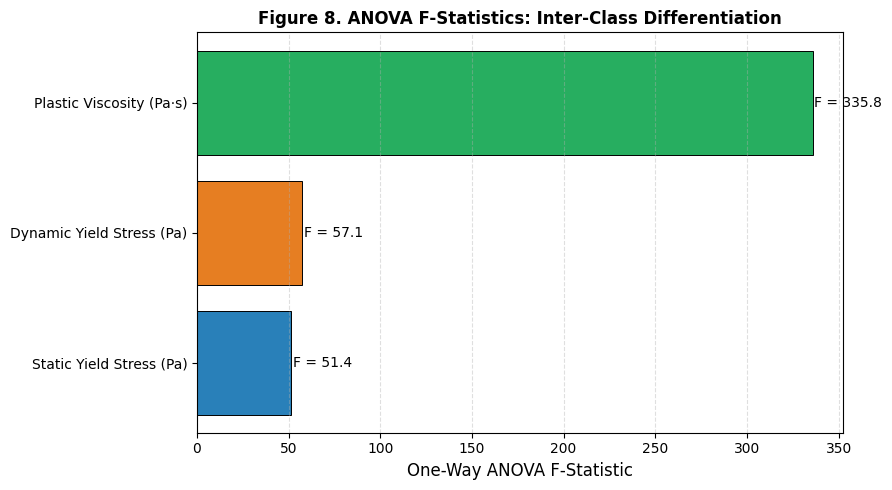

Saved: fig08_anova_fstats.png

SECTION 4 — PREPROCESSING
Standardised features (zero mean, unit variance).
Train / Test split (80/20 stratified):  143 / 36
  Train class counts: {'Bauxite tailings': 24, 'Bentonite': 24, 'Metakaolin': 24, 'Nano-kaolin clay': 24, 'SAPs': 24, 'SP+R+A': 23}
  Test  class counts: {'Bauxite tailings': 6, 'Bentonite': 6, 'Metakaolin': 6, 'Nano-kaolin clay': 6, 'SAPs': 6, 'SP+R+A': 6}

SECTION 5 — CLASSIFIER TRAINING AND EVALUATION

Classifier              Test Acc   Bal.Acc  Macro F1        κ     CV Acc      CV F1
──────────────────────────────────────────────────────────────────────────────────
Random Forest              0.917     0.917     0.916    0.900   0.955±0.022   0.954±0.024
Gradient Boosting          0.944     0.944     0.944    0.933   0.944±0.030   0.944±0.031
k-NN (k=3)                 0.944     0.944     0.943    0.933   0.972±0.030   0.971±0.032
k-NN (k=5)                 0.944     0.944     0.943    0.933   0.939±0.041   0.937±0.043
Logistic R

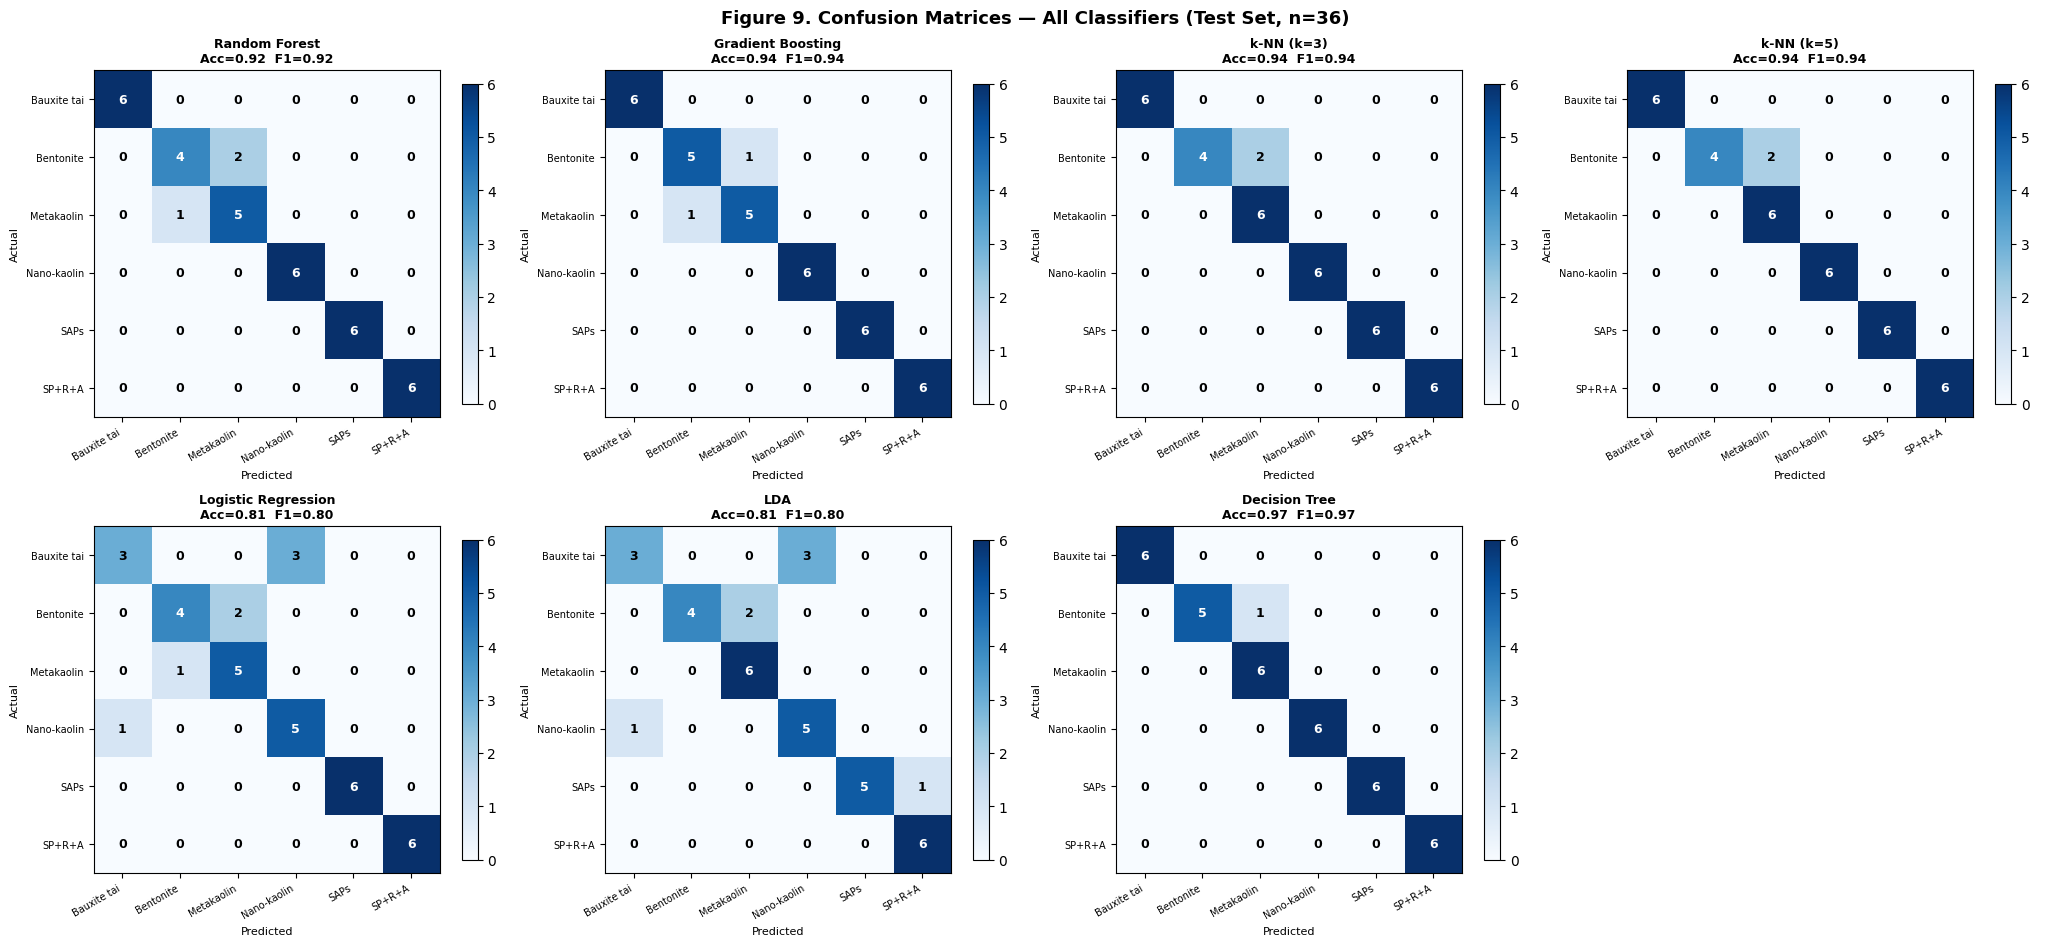

Saved: fig09_confusion_matrices.png


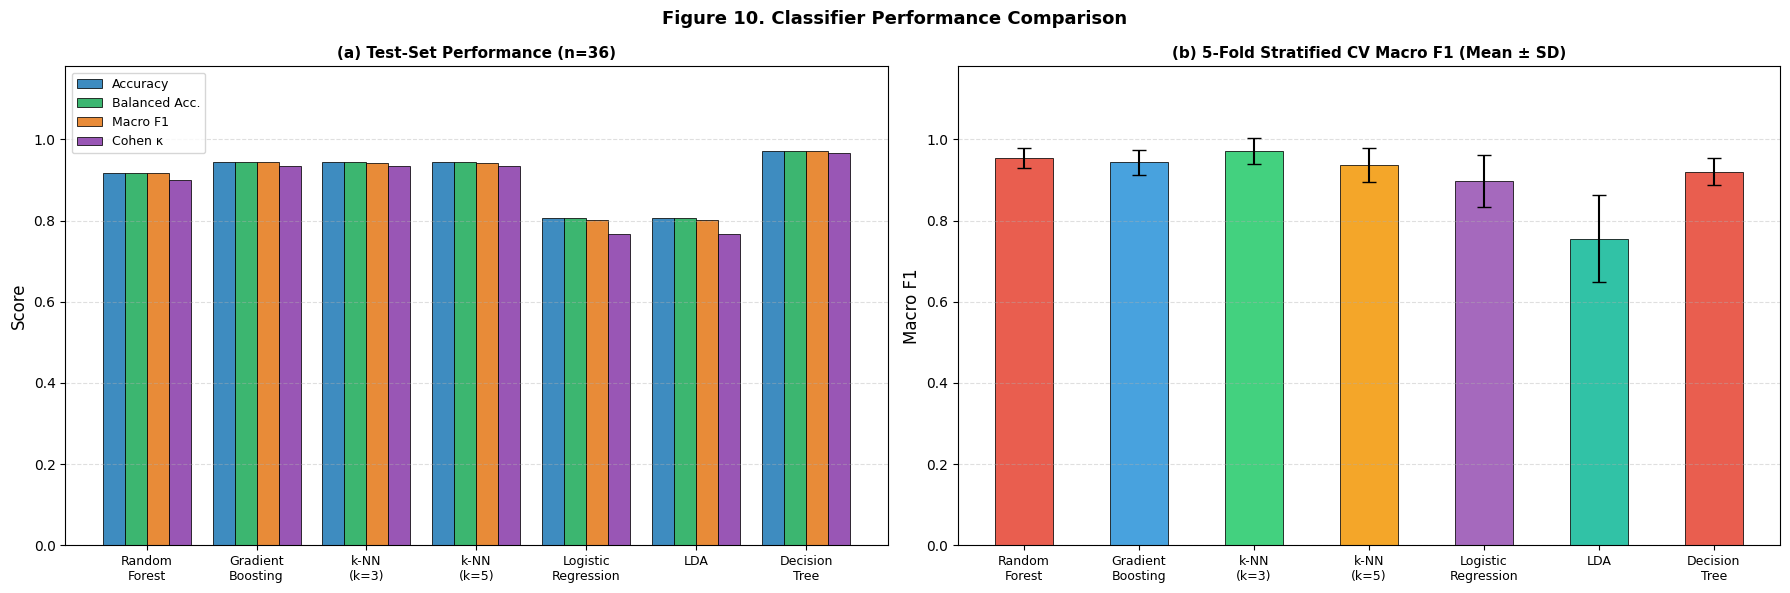

Saved: fig10_performance_comparison.png

SECTION 8 — ROC CURVES (One-vs-Rest)


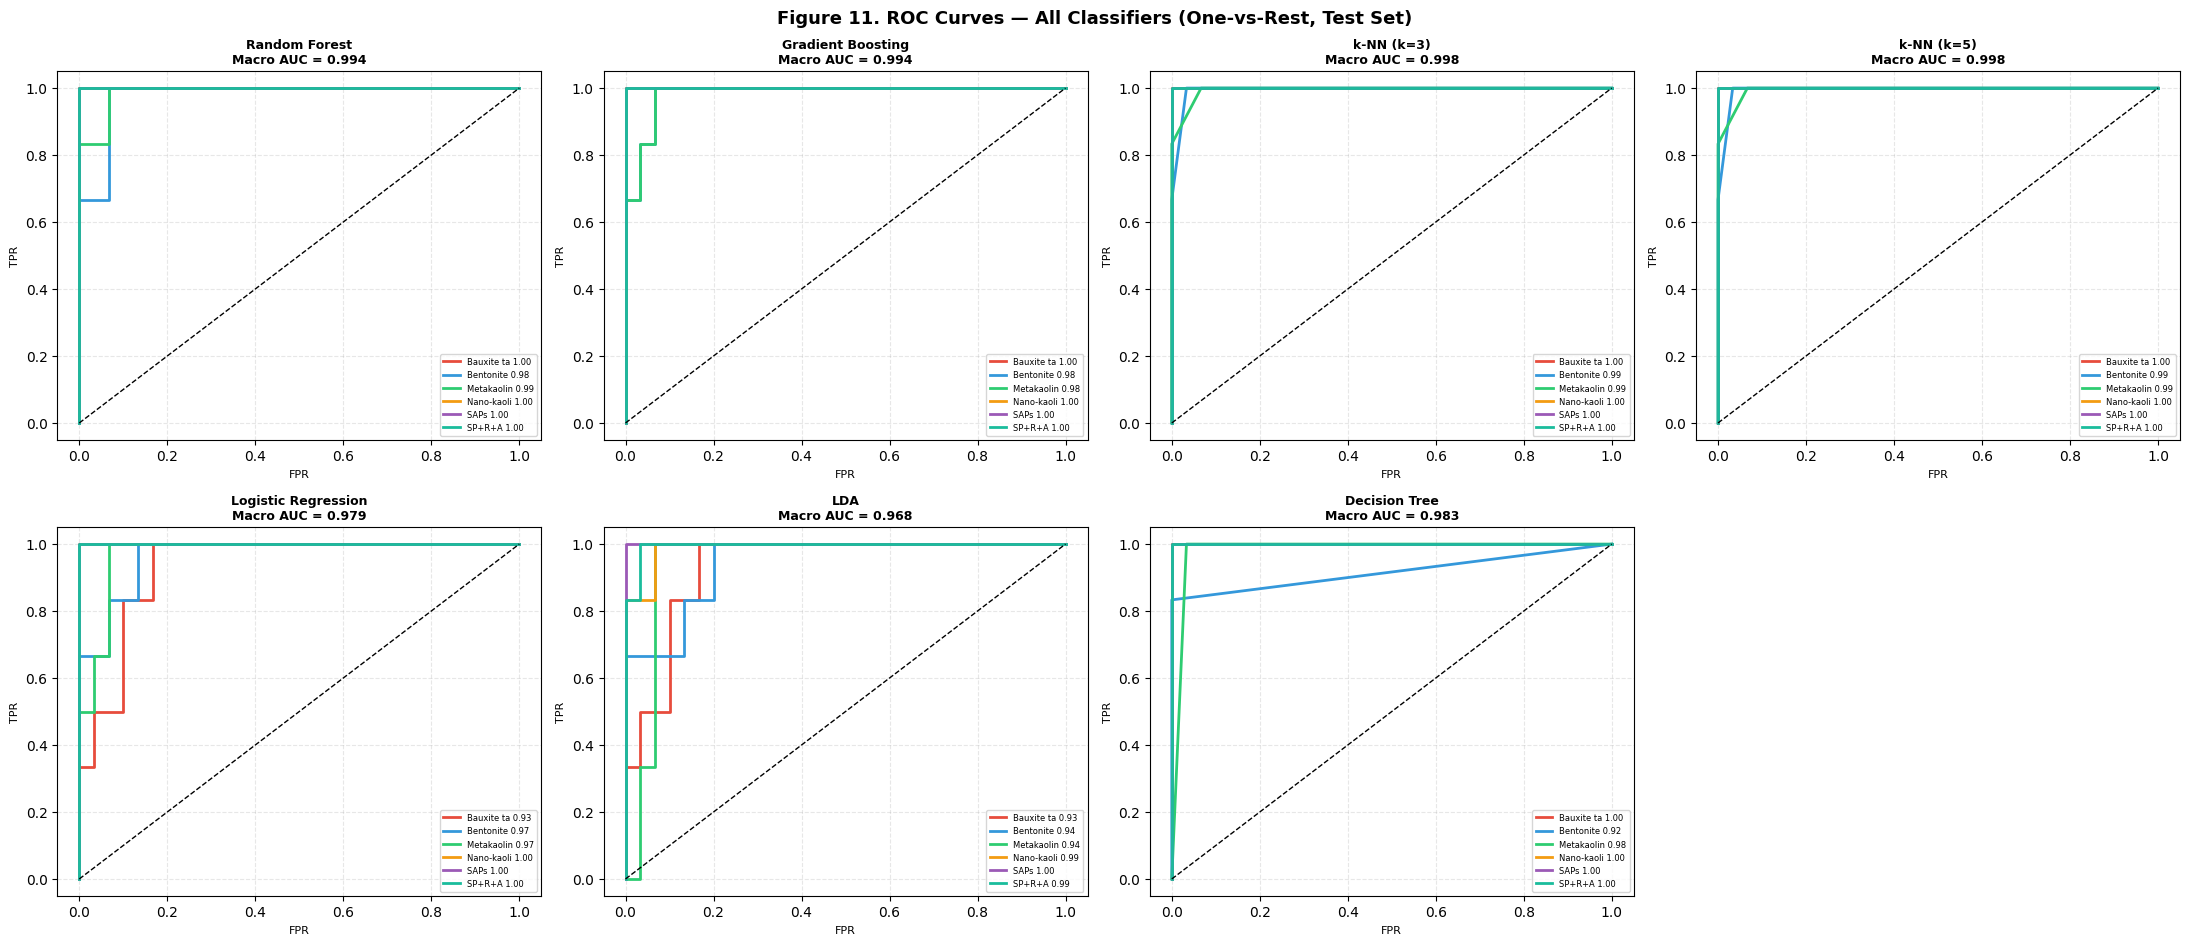


AUC-ROC Summary:
         Classifier  Macro AUC
         k-NN (k=3)      0.998
         k-NN (k=5)      0.998
      Random Forest      0.994
  Gradient Boosting      0.994
      Decision Tree      0.983
Logistic Regression      0.979
                LDA      0.968
Saved: fig11_roc_curves.png

SECTION 9 — FEATURE IMPORTANCE

Feature Importance Table:
                  Feature  Gini RF  Gini GB  Perm Mean  Perm SD
 Plastic Viscosity (Pa·s)   0.3880   0.4898     0.4506   0.0861
Dynamic Yield Stress (Pa)   0.3726   0.3988     0.3167   0.0687
 Static Yield Stress (Pa)   0.2394   0.1114     0.1778   0.0585


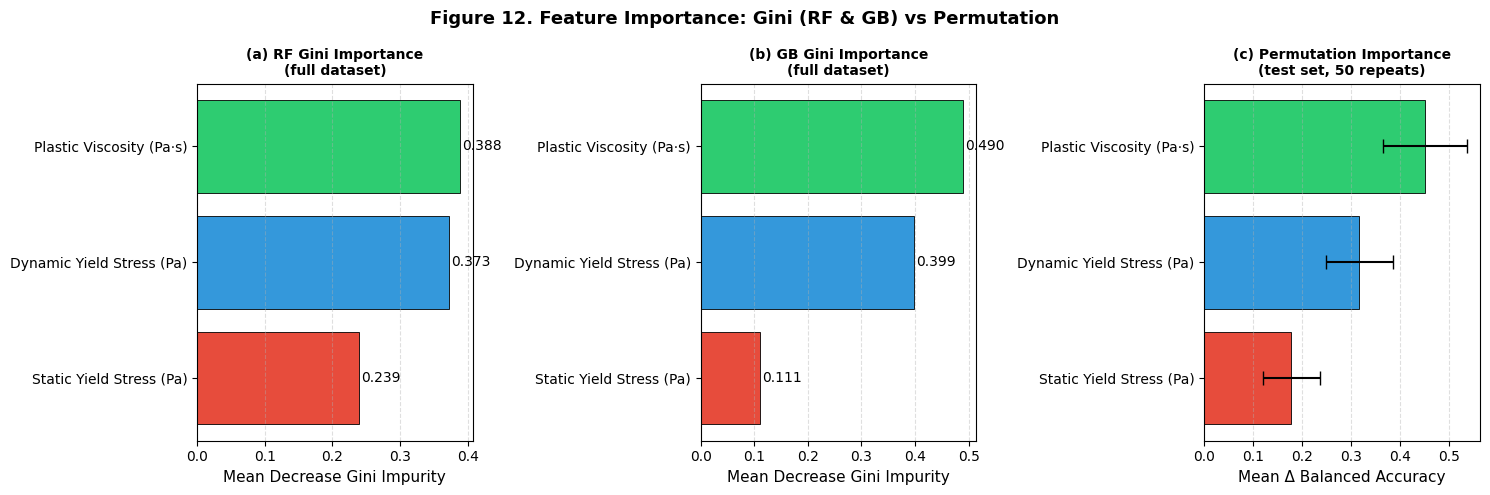

Saved: fig12_feature_importance.png

SECTION 10 — FEATURE ABLATION
                  Removed  Mean F1     SD   Drop
          None (baseline)   0.9540 0.0242 0.0000
 Static Yield Stress (Pa)   0.9037 0.0135 0.0504
Dynamic Yield Stress (Pa)   0.9196 0.0282 0.0344
 Plastic Viscosity (Pa·s)   0.8748 0.0426 0.0792


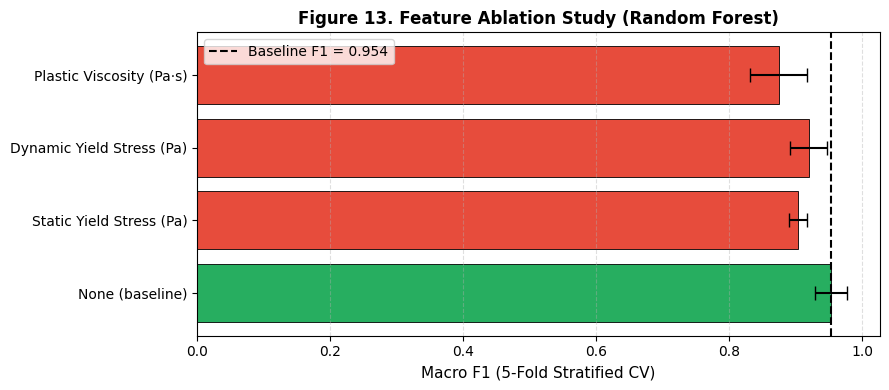

Saved: fig13_ablation.png

SECTION 11 — LEARNING CURVES


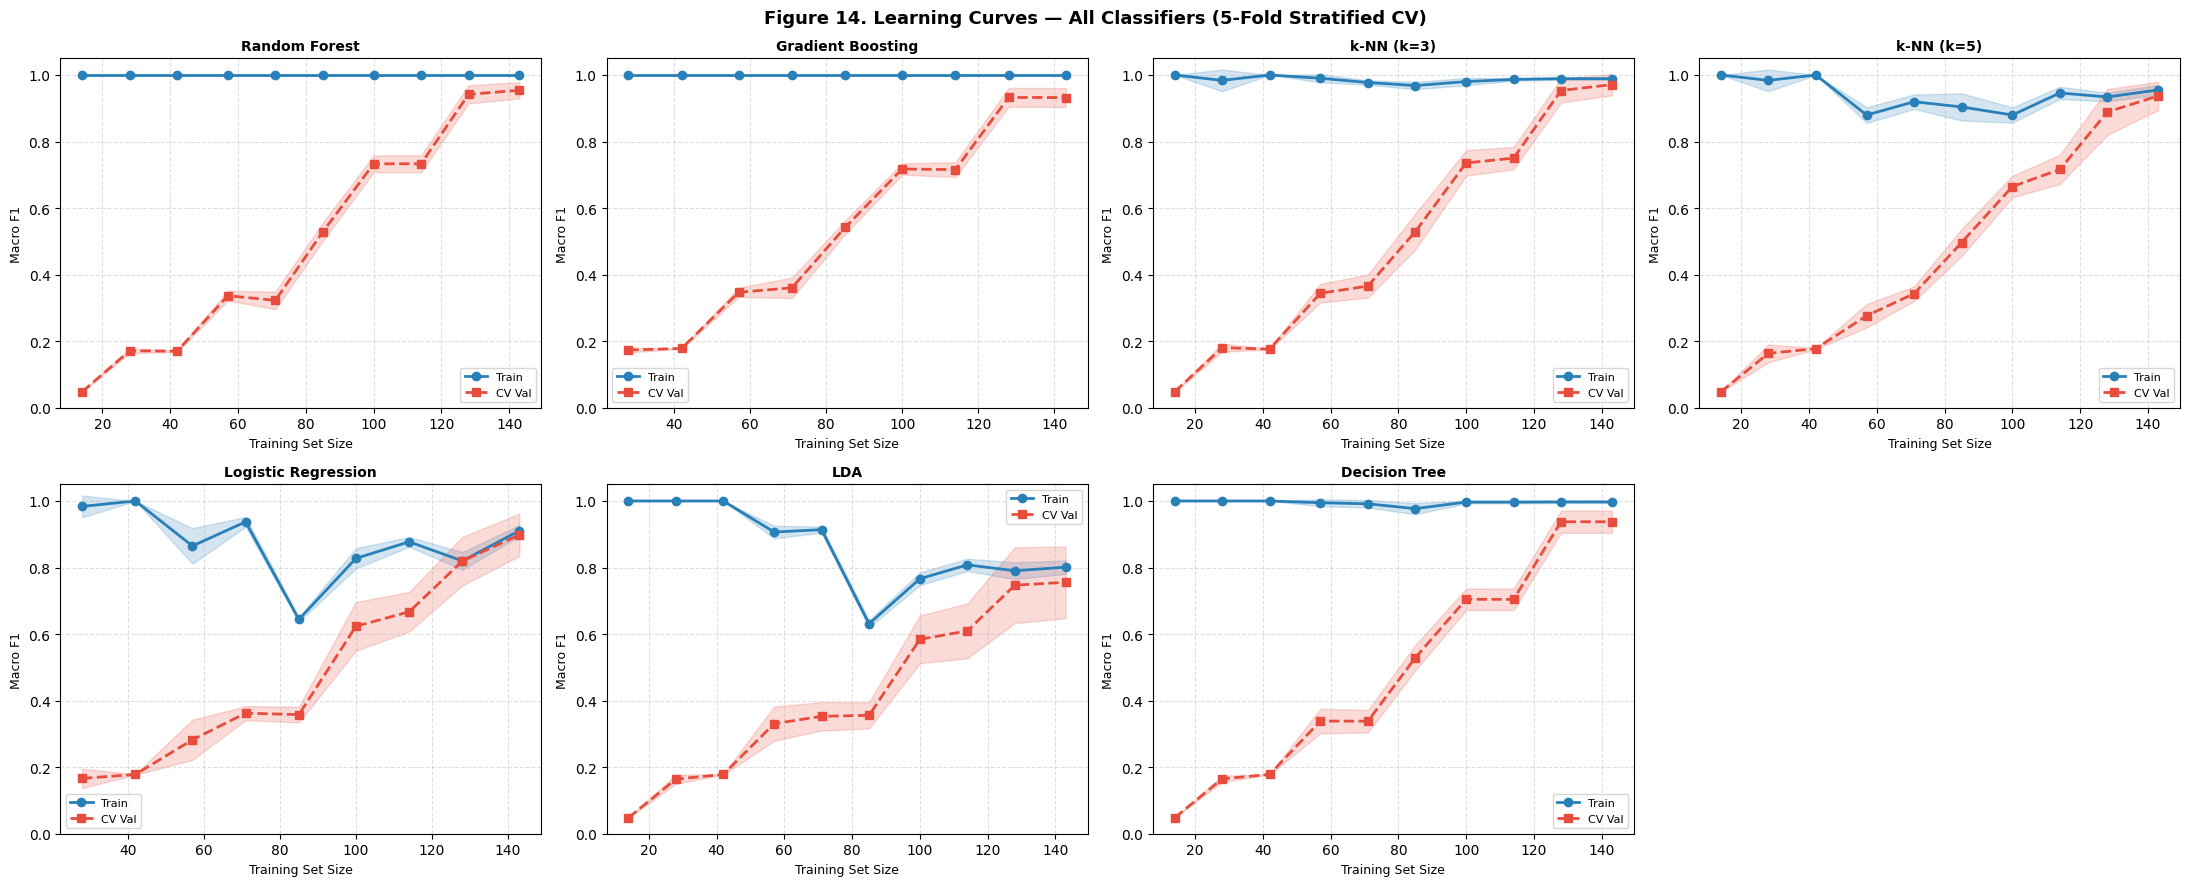

Saved: fig14_learning_curves.png

SECTION 12 — DECISION TREE VISUALIZATION
Decision Tree (depth=4): Acc=0.917  F1=0.916


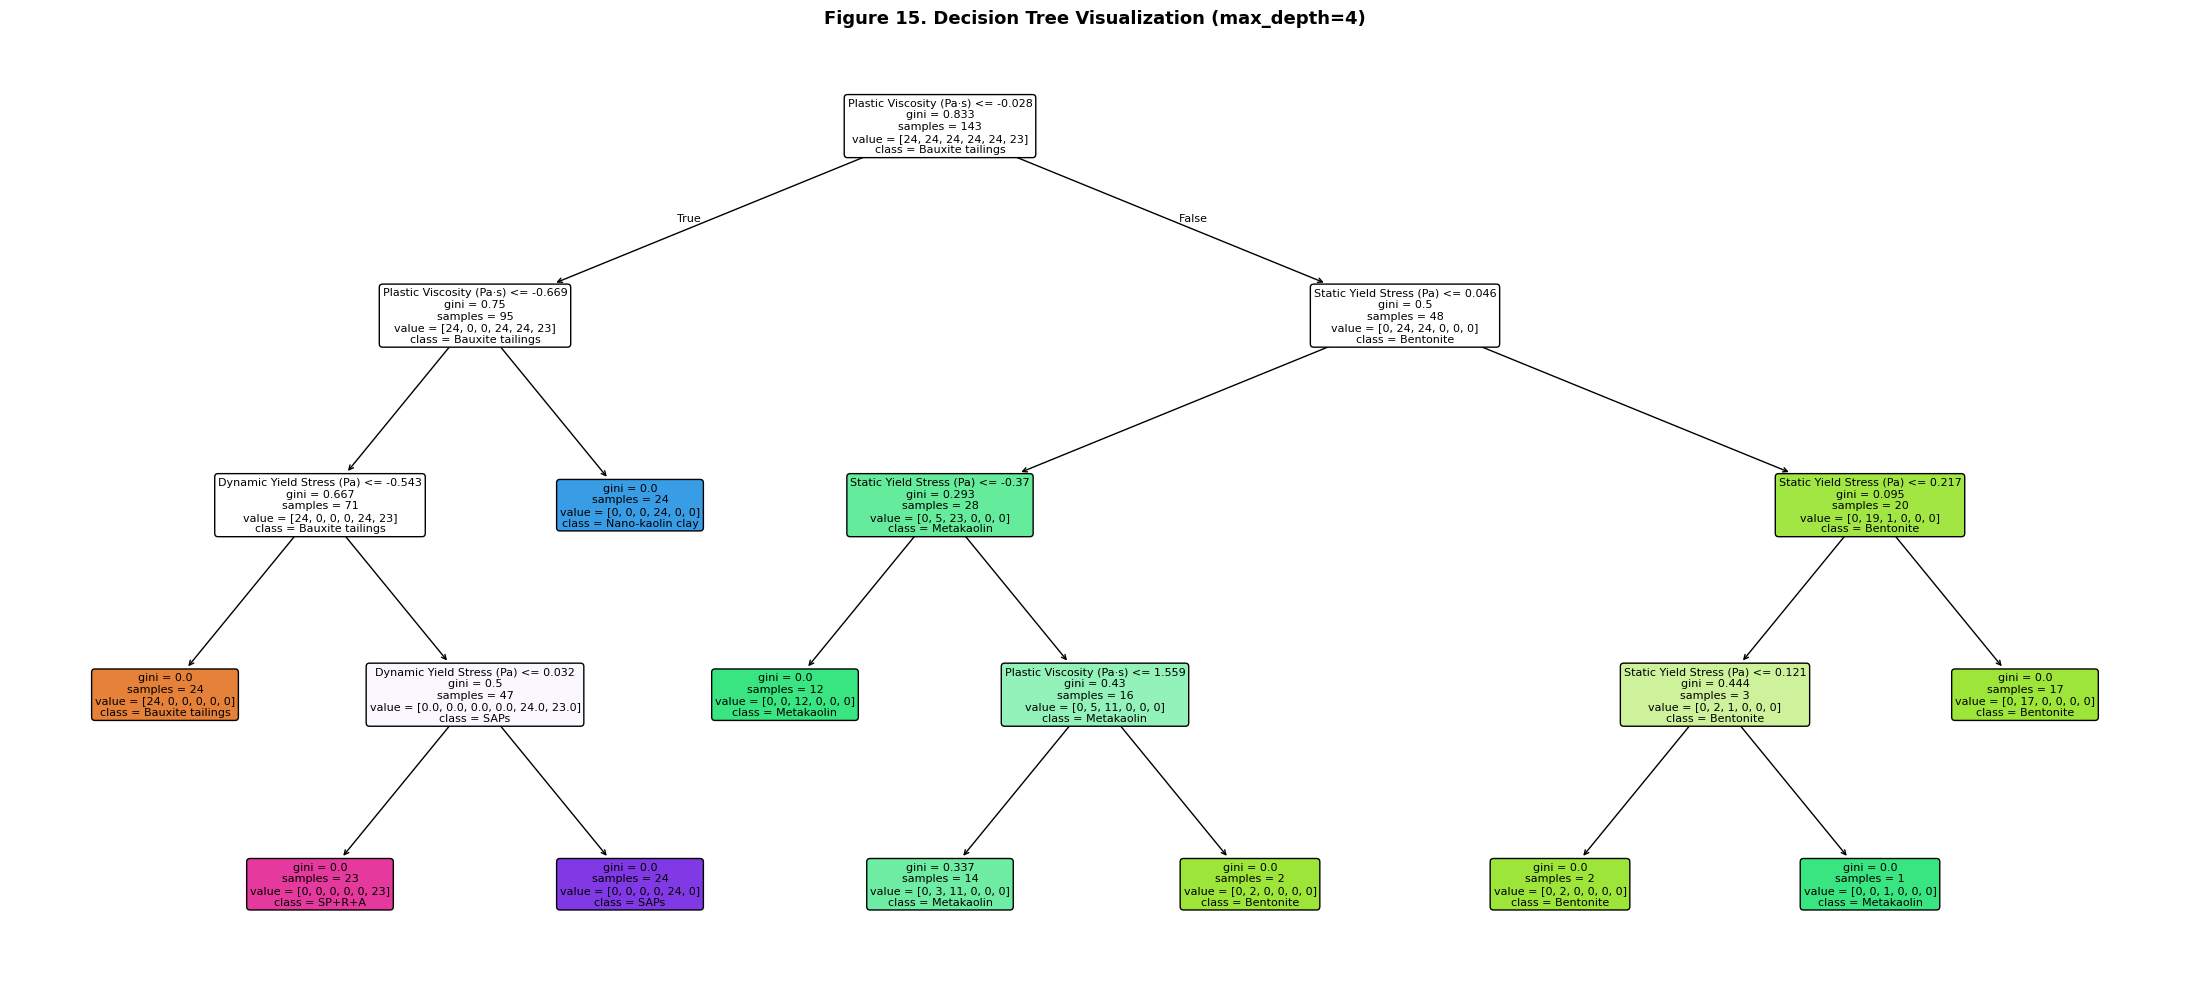


Decision Tree Text Rules:
|--- Plastic Viscosity (Pa·s) <= -0.03
|   |--- Plastic Viscosity (Pa·s) <= -0.67
|   |   |--- Dynamic Yield Stress (Pa) <= -0.54
|   |   |   |--- class: 0
|   |   |--- Dynamic Yield Stress (Pa) >  -0.54
|   |   |   |--- Dynamic Yield Stress (Pa) <= 0.03
|   |   |   |   |--- class: 5
|   |   |   |--- Dynamic Yield Stress (Pa) >  0.03
|   |   |   |   |--- class: 4
|   |--- Plastic Viscosity (Pa·s) >  -0.67
|   |   |--- class: 3
|--- Plastic Viscosity (Pa·s) >  -0.03
|   |--- Static Yield Stress (Pa) <= 0.05
|   |   |--- Static Yield Stress (Pa) <= -0.37
|   |   |   |--- class: 2
|   |   |--- Static Yield Stress (Pa) >  -0.37
|   |   |   |--- Plastic Viscosity (Pa·s) <= 1.56
|   |   |   |   |--- class: 2
|   |   |   |--- Plastic Viscosity (Pa·s) >  1.56
|   |   |   |   |--- class: 1
|   |--- Static Yield Stress (Pa) >  0.05
|   |   |--- Static Yield Stress (Pa) <= 0.22
|   |   |   |--- Static Yield Stress (Pa) <= 0.12
|   |   |   |   |--- class: 1
|   |   |   |

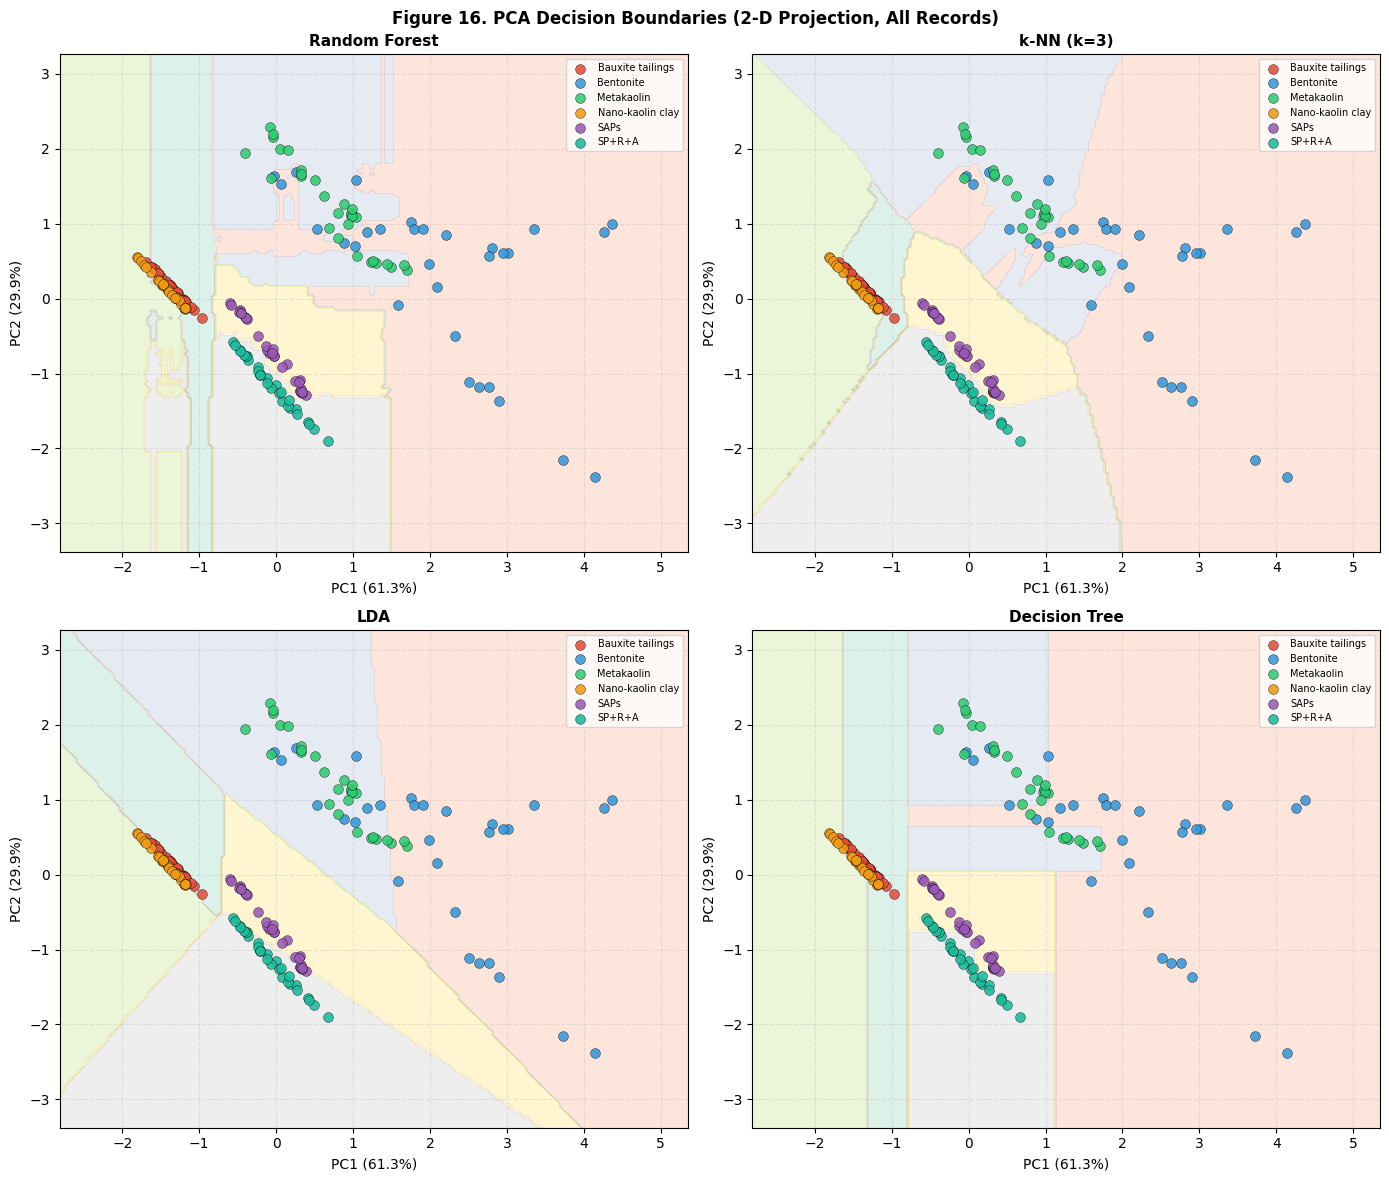

Saved: fig16_decision_boundaries.png

SECTION 14 — HYPERPARAMETER TUNING (GridSearchCV)

── Tuning Random Forest ──
  Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1  : 0.9540

── Tuning k-NN ──
  Best params : {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
  Best CV F1  : 0.9710

── Tuning Gradient Boosting ──
  Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
  Best CV F1  : 0.9494

── Tuned Models on Test Set ──
  Model                 Test Acc   Test F1        κ
  ──────────────────────────────────────────────────
  Tuned RF                 1.000     1.000    1.000
  Tuned k-NN               1.000     1.000    1.000
  Tuned GB                 1.000     1.000    1.000


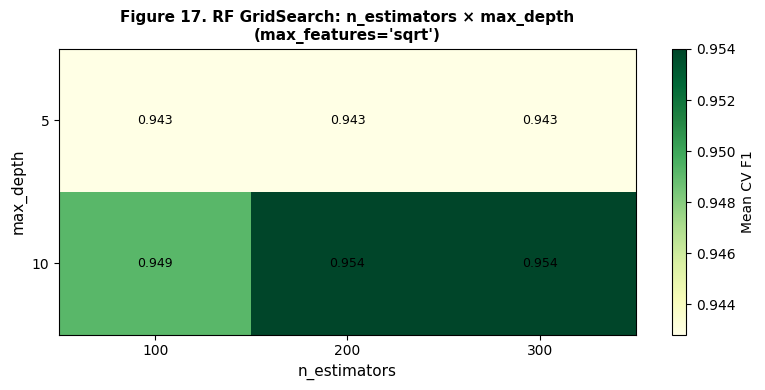

Saved: fig17_gridsearch_rf.png

SECTION 15 — SHAP VALUES

Mean |SHAP| per feature (averaged across all classes):
  Static Yield Stress (Pa)           : 0.1044
  Dynamic Yield Stress (Pa)          : 0.1108
  Plastic Viscosity (Pa·s)           : 0.1060
SHAP error: list index out of range

SECTION 16 — FULL PERFORMANCE SUMMARY TABLE
         Classifier  Test Accuracy  Balanced Acc.  Macro Precision  Macro Recall  Macro F1  Cohen κ  CV Acc Mean  CV Acc SD  CV F1 Mean  CV F1 SD
      Random Forest          0.917          0.917            0.919         0.917     0.916    0.900        0.955      0.022       0.954     0.024
  Gradient Boosting          0.944          0.944            0.944         0.944     0.944    0.933        0.944      0.030       0.944     0.031
         k-NN (k=3)          0.944          0.944            0.958         0.944     0.943    0.933        0.972      0.030       0.971     0.032
         k-NN (k=5)          0.944          0.944            0.958         0.944    

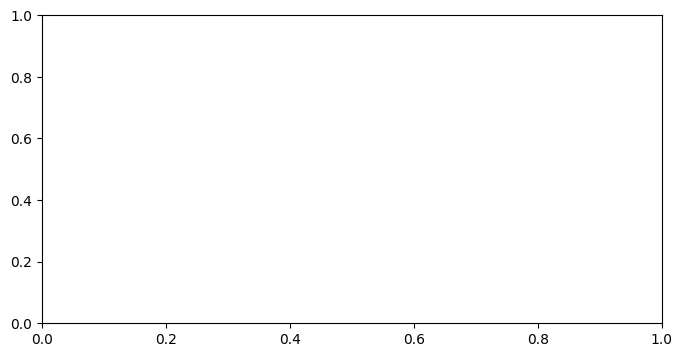

In [11]:
# =============================================================================
# 3DPC RHEOLOGY — ADMIXTURE CLASSIFICATION ANALYSIS
# Dataset : Final_3DPC_model_ready_180_balanced.csv
# Records : 180  |  Classes : 6  |  Features : 3  |  Balanced : 30 per class
# All 180 records are treated as one unified dataset.
# =============================================================================
# HOW TO USE IN GOOGLE COLAB
# 1. Upload your CSV file (Files panel → Upload, or run the two lines below)
# 2. Run all cells from top to bottom
#
#    from google.colab import files
#    files.upload()   # select  Final_3DPC_model_ready_180_balanced.csv
# =============================================================================

# ── Uncomment to install missing packages on a fresh Colab session ────────────
# !pip install scikit-learn scipy matplotlib seaborn shap -q

import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

from scipy.stats import f_oneway, kruskal, mannwhitneyu, spearmanr

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve, GridSearchCV,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    cohen_kappa_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve,
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

print("All libraries imported successfully.")

# =============================================================================
# SECTION 1 — LOAD DATA
# =============================================================================

FILE_PATH = "Final_3DPC_model_ready_180_balanced.csv"   # ← change if needed

df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# ── Define features and target ────────────────────────────────────────────────
FEAT_COLS   = [
    "Static_Yield_Stress_Pa",
    "Dynamic_Yield_Stress_Pa",
    "Plastic_Viscosity_Pa_s",
]
FEAT_LABELS = [
    "Static Yield Stress (Pa)",
    "Dynamic Yield Stress (Pa)",
    "Plastic Viscosity (Pa·s)",
]
CLASS_COL = "Admixture_Class"

# ── Encode class labels ───────────────────────────────────────────────────────
le      = LabelEncoder()
df["y"] = le.fit_transform(df[CLASS_COL])
CLASSES = le.classes_          # alphabetical order
N_CLS   = len(CLASSES)
COLORS  = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6","#1abc9c"]

X = df[FEAT_COLS].values
y = df["y"].values

print(f"\nFeatures : {FEAT_LABELS}")
print(f"Classes  : {list(CLASSES)}")
print(f"\nClass distribution (n per class):")
for cls, cnt in df[CLASS_COL].value_counts().sort_index().items():
    print(f"  {cls:<20}: {cnt}")

# =============================================================================
# SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

print("\n" + "="*65)
print("SECTION 2 — EXPLORATORY DATA ANALYSIS")
print("="*65)

# ── 2A. Overall descriptive statistics ───────────────────────────────────────
print("\n── 2A. Overall Descriptive Statistics (n=180) ──")
overall = df[FEAT_COLS].describe().round(3)
print(overall.to_string())

# ── 2B. Class-wise descriptive statistics ────────────────────────────────────
print("\n── 2B. Class-Wise Descriptive Statistics ──")
rows = []
for cls in CLASSES:
    sub = df[df[CLASS_COL] == cls]
    row = {"Class": cls, "n": len(sub)}
    for fc, fl in zip(FEAT_COLS, FEAT_LABELS):
        row[f"{fl[:12]} Mean"] = round(sub[fc].mean(), 3)
        row[f"{fl[:12]} SD"]   = round(sub[fc].std(),  3)
        row[f"{fl[:12]} Min"]  = round(sub[fc].min(),  3)
        row[f"{fl[:12]} Max"]  = round(sub[fc].max(),  3)
    rows.append(row)
stats_df = pd.DataFrame(rows)

# Print one feature at a time for readability
for fc, fl in zip(FEAT_COLS, FEAT_LABELS):
    print(f"\n  {fl}:")
    tmp = stats_df[["Class","n",
                     f"{fl[:12]} Mean", f"{fl[:12]} SD",
                     f"{fl[:12]} Min",  f"{fl[:12]} Max"]]
    print(tmp.to_string(index=False))

# ── 2C. One-way ANOVA and Kruskal-Wallis ─────────────────────────────────────
print("\n── 2C. One-Way ANOVA and Kruskal-Wallis Tests ──")
print(f"  {'Feature':<30} {'F-stat':>9} {'p(ANOVA)':>12}  {'H-stat':>9} {'p(KW)':>12}")
print("  " + "─"*76)
anova_rows = []
for fc, fl in zip(FEAT_COLS, FEAT_LABELS):
    groups = [df[df[CLASS_COL]==c][fc].values for c in CLASSES]
    F, pF  = f_oneway(*groups)
    H, pH  = kruskal(*groups)
    sig_F  = "***" if pF<0.001 else ("**" if pF<0.01 else "*" if pF<0.05 else "")
    sig_H  = "***" if pH<0.001 else ("**" if pH<0.01 else "*" if pH<0.05 else "")
    print(f"  {fl:<30} {F:>9.2f} {pF:>12.3e}{sig_F}  {H:>9.2f} {pH:>12.3e}{sig_H}")
    anova_rows.append({"Feature":fl, "F":round(F,2), "p_ANOVA":round(pF,5),
                        "H":round(H,2), "p_KW":round(pH,5)})
anova_df = pd.DataFrame(anova_rows)
print("  *** p<0.001  ** p<0.01  * p<0.05")

# ── 2D. Pairwise Mann-Whitney U tests ────────────────────────────────────────
print("\n── 2D. Pairwise Mann-Whitney U Tests ──")
mw_rows = []
for fc, fl in zip(FEAT_COLS, FEAT_LABELS):
    print(f"\n  {fl}:")
    print(f"    {'Pair':<42} {'U-stat':>8} {'p-value':>12} {'Sig':>5}")
    for cls_a, cls_b in combinations(CLASSES, 2):
        ga = df[df[CLASS_COL]==cls_a][fc].values
        gb = df[df[CLASS_COL]==cls_b][fc].values
        U, p = mannwhitneyu(ga, gb, alternative="two-sided")
        sig  = "***" if p<0.001 else ("**" if p<0.01 else "*" if p<0.05 else "ns")
        pair = f"{cls_a[:18]} vs {cls_b[:18]}"
        print(f"    {pair:<42} {U:>8.0f} {p:>12.3e} {sig:>5}")
        mw_rows.append({"Feature":fl,"Pair":pair,"U":round(U),"p":round(p,5),"Sig":sig})
mw_df = pd.DataFrame(mw_rows)

# ── 2E. Correlation matrices ──────────────────────────────────────────────────
print("\n── 2E. Pearson Correlation Matrix ──")
corr_p = pd.DataFrame(X, columns=FEAT_LABELS).corr(method="pearson").round(3)
print(corr_p.to_string())

print("\n── 2E. Spearman Correlation Matrix ──")
corr_s = pd.DataFrame(X, columns=FEAT_LABELS).corr(method="spearman").round(3)
print(corr_s.to_string())

# =============================================================================
# SECTION 3 — EDA FIGURES
# =============================================================================

print("\n" + "="*65)
print("SECTION 3 — EDA FIGURES")
print("="*65)

# ── Figure 1: Class distribution bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
counts = df[CLASS_COL].value_counts().reindex(CLASSES)
bars   = ax.bar(CLASSES, counts.values, color=COLORS,
                edgecolor="black", linewidth=0.7)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Admixture-System Category", fontsize=12)
ax.set_ylabel("Number of Records", fontsize=12)
ax.set_title("Figure 1. Class Distribution (n=180, 30 per class)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(CLASSES, rotation=18, ha="right", fontsize=10)
ax.set_ylim(0, 38)
ax.grid(axis="y", linestyle="--", alpha=0.45)
plt.tight_layout()
plt.savefig("fig01_class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig01_class_distribution.png")

# ── Figure 2: Box plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, fc, fl in zip(axes, FEAT_COLS, FEAT_LABELS):
    data = [df[df[CLASS_COL]==c][fc].values for c in CLASSES]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.52,
                      medianprops={"color":"black","linewidth":2.2},
                      flierprops={"marker":"o","markersize":4,"alpha":0.6})
    for patch, col in zip(bp["boxes"], COLORS):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.set_xticklabels([c.replace(" ","\n") for c in CLASSES], fontsize=9)
    ax.set_ylabel(fl, fontsize=11)
    ax.set_title(fl, fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.suptitle("Figure 2. Box Plots of Rheological Features by Admixture Class (n=180)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig02_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig02_boxplots.png")

# ── Figure 3: Violin plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, fc, fl in zip(axes, FEAT_COLS, FEAT_LABELS):
    data  = [df[df[CLASS_COL]==c][fc].values for c in CLASSES]
    parts = ax.violinplot(data, positions=range(1, N_CLS+1),
                          showmeans=True, showmedians=True)
    for pc, col in zip(parts["bodies"], COLORS):
        pc.set_facecolor(col); pc.set_alpha(0.68)
    parts["cmeans"].set_color("red")
    parts["cmedians"].set_color("black")
    ax.set_xticks(range(1, N_CLS+1))
    ax.set_xticklabels([c.replace(" ","\n") for c in CLASSES], fontsize=9)
    ax.set_ylabel(fl, fontsize=11)
    ax.set_title(fl, fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.suptitle("Figure 3. Violin Plots of Rheological Features by Admixture Class (n=180)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig03_violins.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig03_violins.png")

# ── Figure 4: Strip / dot plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
np.random.seed(42)
for ax, fc, fl in zip(axes, FEAT_COLS, FEAT_LABELS):
    for i, (cls, col) in enumerate(zip(CLASSES, COLORS)):
        vals   = df[df[CLASS_COL]==cls][fc].values
        jitter = np.random.uniform(-0.22, 0.22, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=col, s=45, alpha=0.75,
                   edgecolors="black", linewidth=0.3)
        ax.hlines(np.mean(vals), i-0.3, i+0.3,
                  color="black", linewidth=1.8, zorder=5)
    ax.set_xticks(range(N_CLS))
    ax.set_xticklabels([c.replace(" ","\n") for c in CLASSES], fontsize=9)
    ax.set_ylabel(fl, fontsize=11)
    ax.set_title(fl, fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.suptitle("Figure 4. Strip Plots with Class Means (─) by Admixture Category",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig04_stripplots.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig04_stripplots.png")

# ── Figure 5: Pair scatter matrix ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for i, (fi, fli) in enumerate(zip(FEAT_COLS, FEAT_LABELS)):
    for j, (fj, flj) in enumerate(zip(FEAT_COLS, FEAT_LABELS)):
        ax = axes[i][j]
        if i == j:
            for k, (cls, col) in enumerate(zip(CLASSES, COLORS)):
                vals = df[df[CLASS_COL]==cls][fi].values
                ax.hist(vals, bins=10, alpha=0.55, color=col, density=True)
        else:
            for k, (cls, col) in enumerate(zip(CLASSES, COLORS)):
                sub = df[df[CLASS_COL]==cls]
                ax.scatter(sub[fj], sub[fi], color=col,
                           alpha=0.55, s=22, edgecolors="none")
        if i == 2: ax.set_xlabel(flj.replace(" (","\n("), fontsize=8)
        if j == 0: ax.set_ylabel(fli.replace(" (","\n("), fontsize=8)
        ax.tick_params(labelsize=7)
handles = [mpatches.Patch(color=COLORS[k], label=cls)
           for k, cls in enumerate(CLASSES)]
fig.legend(handles=handles, loc="upper right", fontsize=9, ncol=2,
           bbox_to_anchor=(1.0, 1.0))
plt.suptitle("Figure 5. Pair Scatter Matrix of Rheological Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig05_pairscatter.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig05_pairscatter.png")

# ── Figure 6: Correlation heatmaps ────────────────────────────────────────────
short_fl = ["Static YS\n(Pa)", "Dynamic YS\n(Pa)", "Plastic Visc.\n(Pa·s)"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cmat, title in zip(
    axes,
    [corr_p.values, corr_s.values],
    ["Pearson Correlation", "Spearman Correlation"]
):
    im = ax.imshow(cmat, cmap="RdYlBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label="r")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(short_fl, fontsize=10)
    ax.set_yticklabels(short_fl, fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cmat[i,j]:.3f}", ha="center", va="center",
                    fontsize=12, fontweight="bold",
                    color="white" if abs(cmat[i,j]) > 0.7 else "black")
    ax.set_title(title, fontsize=12, fontweight="bold")
plt.suptitle("Figure 6. Correlation Matrices of Rheological Input Features (n=180)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig06_correlations.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig06_correlations.png")

# ── Figure 7: PCA score plot ──────────────────────────────────────────────────
scaler_pca = StandardScaler()
X_pca_s    = scaler_pca.fit_transform(X)
pca        = PCA(n_components=3)
X_pc       = pca.fit_transform(X_pca_s)
ev         = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (xi, yi, xl, yl) in zip(axes, [
    (0, 1,
     f"PC1 ({ev[0]*100:.1f}%)", f"PC2 ({ev[1]*100:.1f}%)"),
    (0, 2,
     f"PC1 ({ev[0]*100:.1f}%)", f"PC3 ({ev[2]*100:.1f}%)"),
]):
    for k, (cls, col) in enumerate(zip(CLASSES, COLORS)):
        mask = y == k
        ax.scatter(X_pc[mask, xi], X_pc[mask, yi],
                   c=col, s=55, label=cls,
                   edgecolors="black", linewidth=0.3, alpha=0.85)
    ax.set_xlabel(xl, fontsize=12); ax.set_ylabel(yl, fontsize=12)
    ax.legend(fontsize=8, loc="best")
    ax.grid(linestyle="--", alpha=0.3)

plt.suptitle(f"Figure 7. PCA Score Plots  "
             f"[Total variance explained: {ev.sum()*100:.1f}%]",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig07_pca_scatter.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nPCA Explained Variance:")
for i, v in enumerate(ev):
    print(f"  PC{i+1}: {v*100:.2f}%  (cumulative: {ev[:i+1].sum()*100:.2f}%)")

print("\nPCA Loadings:")
load_df = pd.DataFrame(
    pca.components_.T, index=FEAT_LABELS,
    columns=[f"PC{i+1}" for i in range(3)])
print(load_df.round(4).to_string())
print("Saved: fig07_pca_scatter.png")

# ── Figure 8: ANOVA F-statistic bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
f_vals = anova_df["F"].values
ax.barh(anova_df["Feature"], f_vals,
        color=["#2980b9","#e67e22","#27ae60"],
        edgecolor="black", linewidth=0.7)
for i, v in enumerate(f_vals):
    ax.text(v + 1, i, f"F = {v:.1f}", va="center", fontsize=10)
ax.set_xlabel("One-Way ANOVA F-Statistic", fontsize=12)
ax.set_title("Figure 8. ANOVA F-Statistics: Inter-Class Differentiation",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig08_anova_fstats.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig08_anova_fstats.png")

# =============================================================================
# SECTION 4 — PREPROCESSING
# =============================================================================

print("\n" + "="*65)
print("SECTION 4 — PREPROCESSING")
print("="*65)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print(f"Standardised features (zero mean, unit variance).")
print(f"Train / Test split (80/20 stratified):  {len(X_train)} / {len(X_test)}")
print(f"  Train class counts: "
      f"{dict(zip(CLASSES, [int((y_train==k).sum()) for k in range(N_CLS)]))}")
print(f"  Test  class counts: "
      f"{dict(zip(CLASSES, [int((y_test==k).sum())  for k in range(N_CLS)]))}")

# =============================================================================
# SECTION 5 — TRAIN AND EVALUATE ALL CLASSIFIERS
# =============================================================================

print("\n" + "="*65)
print("SECTION 5 — CLASSIFIER TRAINING AND EVALUATION")
print("="*65)

MODELS = {
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    "k-NN (k=3)"          : KNeighborsClassifier(n_neighbors=3),
    "k-NN (k=5)"          : KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression" : LogisticRegression(max_iter=2000, random_state=42),
    "LDA"                 : LinearDiscriminantAnalysis(),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=6, random_state=42),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, mdl in MODELS.items():
    mdl.fit(X_train, y_train)
    pred  = mdl.predict(X_test)
    proba = mdl.predict_proba(X_test) if hasattr(mdl, "predict_proba") else None
    cv_acc = cross_val_score(type(mdl)(**mdl.get_params()),
                              X_scaled, y, cv=skf, scoring="accuracy")
    cv_f1  = cross_val_score(type(mdl)(**mdl.get_params()),
                              X_scaled, y, cv=skf, scoring="f1_macro")
    results[name] = {
        "model"   : mdl,
        "pred"    : pred,
        "proba"   : proba,
        "acc"     : accuracy_score(y_test, pred),
        "bal"     : balanced_accuracy_score(y_test, pred),
        "f1"      : f1_score(y_test, pred, average="macro",    zero_division=0),
        "prec"    : precision_score(y_test, pred, average="macro", zero_division=0),
        "rec"     : recall_score(y_test, pred, average="macro",    zero_division=0),
        "kap"     : cohen_kappa_score(y_test, pred),
        "cv_acc_m": cv_acc.mean(), "cv_acc_s": cv_acc.std(),
        "cv_f1_m" : cv_f1.mean(),  "cv_f1_s" : cv_f1.std(),
    }

print(f"\n{'Classifier':<22} {'Test Acc':>9} {'Bal.Acc':>9} {'Macro F1':>9} "
      f"{'κ':>8} {'CV Acc':>10} {'CV F1':>10}")
print("─"*82)
for name, r in results.items():
    print(f"{name:<22} {r['acc']:>9.3f} {r['bal']:>9.3f} {r['f1']:>9.3f} "
          f"{r['kap']:>8.3f} "
          f"{r['cv_acc_m']:>7.3f}±{r['cv_acc_s']:.3f} "
          f"{r['cv_f1_m']:>7.3f}±{r['cv_f1_s']:.3f}")

# ── Full classification report for each model ─────────────────────────────────
for name, r in results.items():
    print(f"\n── Classification Report: {name} ──")
    print(classification_report(y_test, r["pred"],
                                 target_names=CLASSES, zero_division=0))

# =============================================================================
# SECTION 6 — CONFUSION MATRICES
# =============================================================================

print("\n" + "="*65)
print("SECTION 6 — CONFUSION MATRICES")
print("="*65)

n_models = len(MODELS)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 4.8*nrows))
flat = axes.flatten()

for ax, (name, r) in zip(flat, results.items()):
    cm = confusion_matrix(y_test, r["pred"])
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(f"{name}\nAcc={r['acc']:.2f}  F1={r['f1']:.2f}",
                 fontsize=9, fontweight="bold")
    ax.set_xticks(range(N_CLS)); ax.set_yticks(range(N_CLS))
    ax.set_xticklabels([c[:11] for c in CLASSES],
                        fontsize=7, rotation=30, ha="right")
    ax.set_yticklabels([c[:11] for c in CLASSES], fontsize=7)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual",    fontsize=8)
    for i in range(N_CLS):
        for j in range(N_CLS):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    plt.colorbar(im, ax=ax, shrink=0.8)

for ax in flat[n_models:]:
    ax.axis("off")

plt.suptitle("Figure 9. Confusion Matrices — All Classifiers (Test Set, n=36)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig09_confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig09_confusion_matrices.png")

# =============================================================================
# SECTION 7 — PERFORMANCE COMPARISON FIGURE
# =============================================================================

names  = list(results.keys())
acc_v  = [results[n]["acc"]  for n in names]
f1_v   = [results[n]["f1"]   for n in names]
kap_v  = [results[n]["kap"]  for n in names]
bal_v  = [results[n]["bal"]  for n in names]
cvf_m  = [results[n]["cv_f1_m"] for n in names]
cvf_s  = [results[n]["cv_f1_s"] for n in names]

x = np.arange(len(names)); w = 0.20

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: test-set metrics
axes[0].bar(x - 1.5*w, acc_v, w, label="Accuracy",
            color="#2980b9", edgecolor="black", linewidth=0.6, alpha=0.9)
axes[0].bar(x - 0.5*w, bal_v, w, label="Balanced Acc.",
            color="#27ae60", edgecolor="black", linewidth=0.6, alpha=0.9)
axes[0].bar(x + 0.5*w, f1_v,  w, label="Macro F1",
            color="#e67e22", edgecolor="black", linewidth=0.6, alpha=0.9)
axes[0].bar(x + 1.5*w, kap_v, w, label="Cohen κ",
            color="#8e44ad", edgecolor="black", linewidth=0.6, alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(" ","\n") for n in names], fontsize=9)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_ylim(0, 1.18)
axes[0].set_title("(a) Test-Set Performance (n=36)",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Right: 5-fold CV F1
axes[1].bar(x, cvf_m, yerr=cvf_s, width=0.5, capsize=5,
            color=COLORS[:len(names)], edgecolor="black", linewidth=0.6, alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(" ","\n") for n in names], fontsize=9)
axes[1].set_ylabel("Macro F1", fontsize=12)
axes[1].set_ylim(0, 1.18)
axes[1].set_title("(b) 5-Fold Stratified CV Macro F1 (Mean ± SD)",
                  fontsize=11, fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Figure 10. Classifier Performance Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig10_performance_comparison.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig10_performance_comparison.png")

# =============================================================================
# SECTION 8 — ROC CURVES
# =============================================================================

print("\n" + "="*65)
print("SECTION 8 — ROC CURVES (One-vs-Rest)")
print("="*65)

y_bin = label_binarize(y_test, classes=range(N_CLS))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.8*nrows))
flat_roc  = axes.flatten()
auc_rows  = []

for ax, (name, r) in zip(flat_roc, results.items()):
    if r["proba"] is None:
        ax.text(0.5, 0.5, "No proba", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(name, fontsize=9)
        continue
    class_aucs = []
    for k, cls in enumerate(CLASSES):
        if y_bin[:, k].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, k], r["proba"][:, k])
        auc_val     = roc_auc_score(y_bin[:, k], r["proba"][:, k])
        class_aucs.append(auc_val)
        ax.plot(fpr, tpr, color=COLORS[k], linewidth=2,
                label=f"{cls[:10]} {auc_val:.2f}")
    macro_auc = np.mean(class_aucs)
    ax.plot([0,1],[0,1], "k--", linewidth=1)
    ax.set_title(f"{name}\nMacro AUC = {macro_auc:.3f}",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("FPR", fontsize=8); ax.set_ylabel("TPR", fontsize=8)
    ax.legend(fontsize=6, loc="lower right")
    ax.grid(linestyle="--", alpha=0.3)
    auc_rows.append({"Classifier": name, "Macro AUC": round(macro_auc, 3)})

for ax in flat_roc[n_models:]:
    ax.axis("off")

plt.suptitle("Figure 11. ROC Curves — All Classifiers (One-vs-Rest, Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig11_roc_curves.png", dpi=180, bbox_inches="tight")
plt.show()

auc_df = pd.DataFrame(auc_rows)
print("\nAUC-ROC Summary:")
print(auc_df.sort_values("Macro AUC", ascending=False).to_string(index=False))
print("Saved: fig11_roc_curves.png")

# =============================================================================
# SECTION 9 — FEATURE IMPORTANCE
# =============================================================================

print("\n" + "="*65)
print("SECTION 9 — FEATURE IMPORTANCE")
print("="*65)

# Train RF and GB on full dataset for importance
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(X_scaled, y)
gb_full = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_full.fit(X_scaled, y)

gini_rf = rf_full.feature_importances_
gini_gb = gb_full.feature_importances_

# Permutation importance on test set
perm = permutation_importance(
    results["Random Forest"]["model"], X_test, y_test,
    n_repeats=50, random_state=42, scoring="balanced_accuracy")

fi_df = pd.DataFrame({
    "Feature"       : FEAT_LABELS,
    "Gini RF"       : gini_rf.round(4),
    "Gini GB"       : gini_gb.round(4),
    "Perm Mean"     : perm.importances_mean.round(4),
    "Perm SD"       : perm.importances_std.round(4),
}).sort_values("Gini RF", ascending=False)

print("\nFeature Importance Table:")
print(fi_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gini RF
si_rf = np.argsort(gini_rf)
axes[0].barh(
    [FEAT_LABELS[i] for i in si_rf],
    [gini_rf[i]     for i in si_rf],
    color=[COLORS[i] for i in si_rf],
    edgecolor="black", linewidth=0.6)
for i, v in enumerate(gini_rf[si_rf]):
    axes[0].text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=10)
axes[0].set_xlabel("Mean Decrease Gini Impurity", fontsize=11)
axes[0].set_title("(a) RF Gini Importance\n(full dataset)",
                  fontsize=10, fontweight="bold")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# Gini GB
si_gb = np.argsort(gini_gb)
axes[1].barh(
    [FEAT_LABELS[i] for i in si_gb],
    [gini_gb[i]     for i in si_gb],
    color=[COLORS[i] for i in si_gb],
    edgecolor="black", linewidth=0.6)
for i, v in enumerate(gini_gb[si_gb]):
    axes[1].text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=10)
axes[1].set_xlabel("Mean Decrease Gini Impurity", fontsize=11)
axes[1].set_title("(b) GB Gini Importance\n(full dataset)",
                  fontsize=10, fontweight="bold")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

# Permutation
pm_mean = perm.importances_mean
pm_std  = perm.importances_std
si_pm   = np.argsort(pm_mean)
axes[2].barh(
    [FEAT_LABELS[i] for i in si_pm],
    [pm_mean[i]     for i in si_pm],
    xerr=[pm_std[i] for i in si_pm],
    capsize=5, color=[COLORS[i] for i in si_pm],
    edgecolor="black", linewidth=0.6)
axes[2].set_xlabel("Mean Δ Balanced Accuracy", fontsize=11)
axes[2].set_title("(c) Permutation Importance\n(test set, 50 repeats)",
                  fontsize=10, fontweight="bold")
axes[2].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Figure 12. Feature Importance: Gini (RF & GB) vs Permutation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig12_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig12_feature_importance.png")

# =============================================================================
# SECTION 10 — FEATURE ABLATION
# =============================================================================

print("\n" + "="*65)
print("SECTION 10 — FEATURE ABLATION")
print("="*65)

skf_ab   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ab_rows  = []

base_cv = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_scaled, y, cv=skf_ab, scoring="f1_macro")
ab_rows.append({"Removed": "None (baseline)",
                 "Mean F1": round(base_cv.mean(), 4),
                 "SD"     : round(base_cv.std(),  4),
                 "Drop"   : 0.0})

for i, fl in enumerate(FEAT_LABELS):
    X_ab = np.delete(X_scaled, i, axis=1)
    sc   = cross_val_score(
        RandomForestClassifier(n_estimators=200, random_state=42),
        X_ab, y, cv=skf_ab, scoring="f1_macro")
    drop = base_cv.mean() - sc.mean()
    ab_rows.append({"Removed": fl,
                     "Mean F1": round(sc.mean(), 4),
                     "SD"     : round(sc.std(),  4),
                     "Drop"   : round(drop, 4)})

ab_df = pd.DataFrame(ab_rows)
print(ab_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["#27ae60"] + ["#e74c3c"] * 3
for idx, (_, row) in enumerate(ab_df.iterrows()):
    ax.barh(row["Removed"], row["Mean F1"], xerr=row["SD"],
            capsize=5, color=bar_colors[idx],
            edgecolor="black", linewidth=0.6)
ax.axvline(base_cv.mean(), color="black", linestyle="--", linewidth=1.5,
            label=f"Baseline F1 = {base_cv.mean():.3f}")
ax.set_xlabel("Macro F1 (5-Fold Stratified CV)", fontsize=11)
ax.set_title("Figure 13. Feature Ablation Study (Random Forest)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig13_ablation.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig13_ablation.png")

# =============================================================================
# SECTION 11 — LEARNING CURVES
# =============================================================================

print("\n" + "="*65)
print("SECTION 11 — LEARNING CURVES")
print("="*65)

skf_lc   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ncols_lc = 4
nrows_lc = (n_models + ncols_lc - 1) // ncols_lc

fig, axes_lc = plt.subplots(nrows_lc, ncols_lc,
                              figsize=(5.5*ncols_lc, 4.5*nrows_lc))
flat_lc = axes_lc.flatten()

for ax, (name, mdl) in zip(flat_lc, MODELS.items()):
    m_lc = type(mdl)(**mdl.get_params())
    tr_sz, tr_sc, val_sc = learning_curve(
        m_lc, X_scaled, y, cv=skf_lc,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="f1_macro", n_jobs=-1)
    ax.plot(tr_sz, tr_sc.mean(1), "o-", color="#2980b9",
             label="Train", linewidth=2)
    ax.fill_between(tr_sz,
                     tr_sc.mean(1) - tr_sc.std(1),
                     tr_sc.mean(1) + tr_sc.std(1),
                     alpha=0.20, color="#2980b9")
    ax.plot(tr_sz, val_sc.mean(1), "s--", color="#e74c3c",
             label="CV Val", linewidth=2)
    ax.fill_between(tr_sz,
                     val_sc.mean(1) - val_sc.std(1),
                     val_sc.mean(1) + val_sc.std(1),
                     alpha=0.20, color="#e74c3c")
    ax.set_xlabel("Training Set Size", fontsize=9)
    ax.set_ylabel("Macro F1", fontsize=9)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.4)
    ax.set_ylim(0.0, 1.05)

for ax in flat_lc[n_models:]:
    ax.axis("off")

plt.suptitle("Figure 14. Learning Curves — All Classifiers (5-Fold Stratified CV)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig14_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig14_learning_curves.png")

# =============================================================================
# SECTION 12 — DECISION TREE VISUALIZATION
# =============================================================================

print("\n" + "="*65)
print("SECTION 12 — DECISION TREE VISUALIZATION")
print("="*65)

dt_vis = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_vis.fit(X_train, y_train)
dt_pred = dt_vis.predict(X_test)
print(f"Decision Tree (depth=4): "
      f"Acc={accuracy_score(y_test, dt_pred):.3f}  "
      f"F1={f1_score(y_test, dt_pred, average='macro', zero_division=0):.3f}")

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_vis, feature_names=FEAT_LABELS, class_names=CLASSES,
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=True, proportion=False)
ax.set_title("Figure 15. Decision Tree Visualization (max_depth=4)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig15_decision_tree.png", dpi=180, bbox_inches="tight")
plt.show()

print("\nDecision Tree Text Rules:")
print(export_text(dt_vis, feature_names=FEAT_LABELS))
print("Saved: fig15_decision_tree.png")

# =============================================================================
# SECTION 13 — PCA DECISION BOUNDARIES
# =============================================================================

print("\n" + "="*65)
print("SECTION 13 — PCA DECISION BOUNDARIES")
print("="*65)

pca2   = PCA(n_components=2)
X_pc2  = pca2.fit_transform(X_scaled)
ev2    = pca2.explained_variance_ratio_

models_bd = {
    "Random Forest" : RandomForestClassifier(n_estimators=200, random_state=42),
    "k-NN (k=3)"    : KNeighborsClassifier(n_neighbors=3),
    "LDA"           : LinearDiscriminantAnalysis(),
    "Decision Tree" : DecisionTreeClassifier(max_depth=6, random_state=42),
}

h  = 0.04
x1, x2 = X_pc2[:,0].min()-1, X_pc2[:,0].max()+1
y1, y2 = X_pc2[:,1].min()-1, X_pc2[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x1, x2, h), np.arange(y1, y2, h))

fig, axes_bd = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, m_bd) in zip(axes_bd.flatten(), models_bd.items()):
    m_bd.fit(X_pc2, y)
    Z = m_bd.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.22, cmap="Set2")
    for k, (cls, col) in enumerate(zip(CLASSES, COLORS)):
        mask = y == k
        ax.scatter(X_pc2[mask, 0], X_pc2[mask, 1],
                   c=col, s=50, label=cls,
                   edgecolors="black", linewidth=0.3, alpha=0.88, zorder=3)
    ax.set_xlabel(f"PC1 ({ev2[0]*100:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({ev2[1]*100:.1f}%)", fontsize=10)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.grid(linestyle="--", alpha=0.3)
    ax.legend(fontsize=7, loc="best")

plt.suptitle("Figure 16. PCA Decision Boundaries (2-D Projection, All Records)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig16_decision_boundaries.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig16_decision_boundaries.png")

# =============================================================================
# SECTION 14 — HYPERPARAMETER TUNING
# =============================================================================

print("\n" + "="*65)
print("SECTION 14 — HYPERPARAMETER TUNING (GridSearchCV)")
print("="*65)

skf_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest ─────────────────────────────────────────────────────────────
print("\n── Tuning Random Forest ──")
rf_param_grid = {
    "n_estimators"      : [100, 200, 300],
    "max_depth"         : [None, 5, 10],
    "min_samples_split" : [2, 5, 10],
    "max_features"      : ["sqrt", "log2"],
}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, cv=skf_gs,
    scoring="f1_macro", n_jobs=-1, verbose=0)
rf_gs.fit(X_scaled, y)
print(f"  Best params : {rf_gs.best_params_}")
print(f"  Best CV F1  : {rf_gs.best_score_:.4f}")

# ── k-NN ──────────────────────────────────────────────────────────────────────
print("\n── Tuning k-NN ──")
knn_param_grid = {
    "n_neighbors" : [1, 3, 5, 7, 9, 11],
    "weights"     : ["uniform", "distance"],
    "metric"      : ["euclidean", "manhattan"],
}
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid, cv=skf_gs,
    scoring="f1_macro", n_jobs=-1)
knn_gs.fit(X_scaled, y)
print(f"  Best params : {knn_gs.best_params_}")
print(f"  Best CV F1  : {knn_gs.best_score_:.4f}")

# ── Gradient Boosting ─────────────────────────────────────────────────────────
print("\n── Tuning Gradient Boosting ──")
gb_param_grid = {
    "n_estimators"  : [100, 200, 300],
    "learning_rate" : [0.05, 0.10, 0.20],
    "max_depth"     : [2, 3, 5],
}
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid, cv=skf_gs,
    scoring="f1_macro", n_jobs=-1)
gb_gs.fit(X_scaled, y)
print(f"  Best params : {gb_gs.best_params_}")
print(f"  Best CV F1  : {gb_gs.best_score_:.4f}")

# ── Tuned models on test set ──────────────────────────────────────────────────
print("\n── Tuned Models on Test Set ──")
print(f"  {'Model':<20} {'Test Acc':>9} {'Test F1':>9} {'κ':>8}")
print("  " + "─"*50)
for label, gs in [("Tuned RF",  rf_gs),
                   ("Tuned k-NN", knn_gs),
                   ("Tuned GB",   gb_gs)]:
    p = gs.best_estimator_.predict(X_test)
    print(f"  {label:<20} "
          f"{accuracy_score(y_test,p):>9.3f} "
          f"{f1_score(y_test,p,average='macro',zero_division=0):>9.3f} "
          f"{cohen_kappa_score(y_test,p):>8.3f}")

# ── GridSearch heatmap for RF ─────────────────────────────────────────────────
gs_df = pd.DataFrame(rf_gs.cv_results_)
piv   = (gs_df[gs_df["param_max_features"]=="sqrt"]
         .pivot_table(index="param_max_depth",
                      columns="param_n_estimators",
                      values="mean_test_score", aggfunc="max"))

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(piv.values, cmap="YlGn",
               vmin=piv.values.min(), vmax=piv.values.max(), aspect="auto")
ax.set_xticks(range(len(piv.columns)))
ax.set_yticks(range(len(piv.index)))
ax.set_xticklabels(piv.columns, fontsize=10)
ax.set_yticklabels(piv.index.astype(str), fontsize=10)
ax.set_xlabel("n_estimators", fontsize=11)
ax.set_ylabel("max_depth", fontsize=11)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.values[i,j]:.3f}",
                ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Mean CV F1")
ax.set_title("Figure 17. RF GridSearch: n_estimators × max_depth\n"
             "(max_features='sqrt')", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("fig17_gridsearch_rf.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig17_gridsearch_rf.png")

# =============================================================================
# SECTION 15 — SHAP VALUES
# =============================================================================

print("\n" + "="*65)
print("SECTION 15 — SHAP VALUES")
print("="*65)

try:
    import shap

    rf_shap = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_shap.fit(X_scaled, y)
    explainer   = shap.TreeExplainer(rf_shap)
    shap_values = explainer.shap_values(X_scaled)
    # shap_values: list of arrays, one per class, shape (n_samples, n_features)

    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    print("\nMean |SHAP| per feature (averaged across all classes):")
    for fl, v in zip(FEAT_LABELS, mean_shap):
        print(f"  {fl:<35}: {v:.4f}")

    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    si = np.argsort(mean_shap)
    ax.barh([FEAT_LABELS[i] for i in si],
             [mean_shap[i]   for i in si],
             color=["#8e44ad","#3498db","#e74c3c"][::-1],
             edgecolor="black", linewidth=0.6)
    ax.set_xlabel("Mean |SHAP value| (averaged across all classes)", fontsize=11)
    ax.set_title("Figure 18. SHAP Mean Feature Importance (RF, full dataset)",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("fig18_shap_bar.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved: fig18_shap_bar.png")

    # Beeswarm plot per class
    for ci, cls in enumerate(CLASSES):
        fig, _ = plt.subplots(figsize=(8, 4))
        shap.summary_plot(shap_values[ci], X_scaled,
                          feature_names=FEAT_LABELS,
                          plot_type="dot", show=False)
        plt.title(f"Figure 19-{ci+1}. SHAP Beeswarm — {cls}",
                  fontsize=11, fontweight="bold")
        plt.tight_layout()
        fname = f"fig19_{ci+1}_shap_{cls[:12].replace(' ','_')}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fname}")

except ImportError:
    print("shap not installed. Run:  !pip install shap  then re-run this section.")
except Exception as e:
    print(f"SHAP error: {e}")

# =============================================================================
# SECTION 16 — FULL PERFORMANCE SUMMARY TABLE
# =============================================================================

print("\n" + "="*65)
print("SECTION 16 — FULL PERFORMANCE SUMMARY TABLE")
print("="*65)

summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "Classifier"     : name,
        "Test Accuracy"  : round(r["acc"],  3),
        "Balanced Acc."  : round(r["bal"],  3),
        "Macro Precision": round(r["prec"], 3),
        "Macro Recall"   : round(r["rec"],  3),
        "Macro F1"       : round(r["f1"],   3),
        "Cohen κ"        : round(r["kap"],  3),
        "CV Acc Mean"    : round(r["cv_acc_m"], 3),
        "CV Acc SD"      : round(r["cv_acc_s"], 3),
        "CV F1 Mean"     : round(r["cv_f1_m"],  3),
        "CV F1 SD"       : round(r["cv_f1_s"],  3),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# =============================================================================
# SECTION 17 — SAVE ALL OUTPUTS
# =============================================================================

print("\n" + "="*65)
print("SECTION 17 — SAVING ALL OUTPUTS")
print("="*65)

stats_df.to_csv("table01_descriptive_stats.csv", index=False)
corr_p.to_csv("table02_pearson_correlation.csv")
corr_s.to_csv("table03_spearman_correlation.csv")
anova_df.to_csv("table04_anova_kruskal.csv", index=False)
mw_df.to_csv("table05_mannwhitney.csv", index=False)
fi_df.to_csv("table06_feature_importance.csv", index=False)
ab_df.to_csv("table07_ablation.csv", index=False)
auc_df.to_csv("table08_roc_auc.csv", index=False)
summary_df.to_csv("table09_performance_summary.csv", index=False)

print("CSVs saved:")
for t in ["table01_descriptive_stats.csv","table02_pearson_correlation.csv",
          "table03_spearman_correlation.csv","table04_anova_kruskal.csv",
          "table05_mannwhitney.csv","table06_feature_importance.csv",
          "table07_ablation.csv","table08_roc_auc.csv",
          "table09_performance_summary.csv"]:
    print(f"  {t}")

print("\n" + "="*65)
print("ALL SECTIONS COMPLETE")
print("="*65)
print("""
FIGURES (19 PNG files):
  fig01  Class distribution bar chart
  fig02  Box plots (all 3 features)
  fig03  Violin plots (all 3 features)
  fig04  Strip plots with class means
  fig05  Pair scatter matrix
  fig06  Pearson + Spearman heatmaps
  fig07  PCA score plots (PC1-PC2, PC1-PC3)
  fig08  ANOVA F-statistic bar chart
  fig09  Confusion matrices (all classifiers)
  fig10  Performance comparison (test-set + CV)
  fig11  ROC curves (all classifiers, OvR)
  fig12  Feature importance (RF Gini, GB Gini, Permutation)
  fig13  Feature ablation study
  fig14  Learning curves (all classifiers)
  fig15  Decision tree visualization
  fig16  PCA decision boundaries (4 classifiers)
  fig17  RF GridSearch heatmap
  fig18  SHAP mean bar chart           [requires shap]
  fig19  SHAP beeswarm per class       [requires shap]

TABLES (9 CSV files):
  table01  Class-wise descriptive statistics
  table02  Pearson correlation matrix
  table03  Spearman correlation matrix
  table04  ANOVA + Kruskal-Wallis results
  table05  Pairwise Mann-Whitney U results
  table06  Feature importance (Gini + Permutation)
  table07  Feature ablation
  table08  AUC-ROC per classifier
  table09  Full performance summary
""")

In [ ]:
print("Installing 'shap' library...")
!pip install shap -q
print("'shap' library installed.")

Installing 'shap' library...
'shap' library installed.


### Re-running SHAP Value Generation (Section 15)


SECTION 15 — SHAP VALUES
SHAP values: single 3D array (shape (179, 3, 6))

Mean |SHAP| per feature (averaged across all classes):
  Static Yield Stress (Pa)           : 0.0889
  Dynamic Yield Stress (Pa)          : 0.1037
  Plastic Viscosity (Pa·s)           : 0.1230


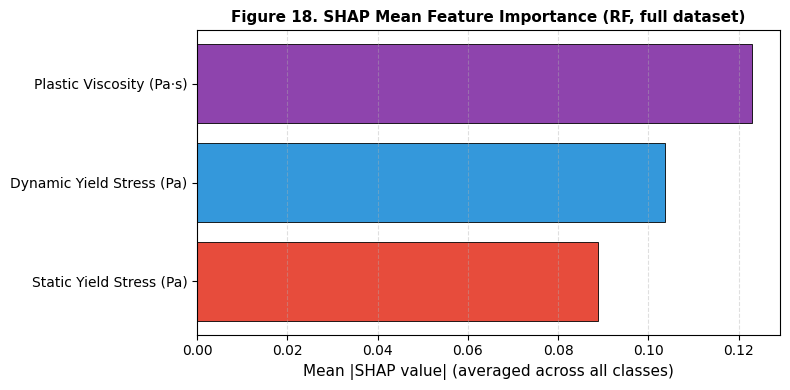

Saved: fig18_shap_bar.png


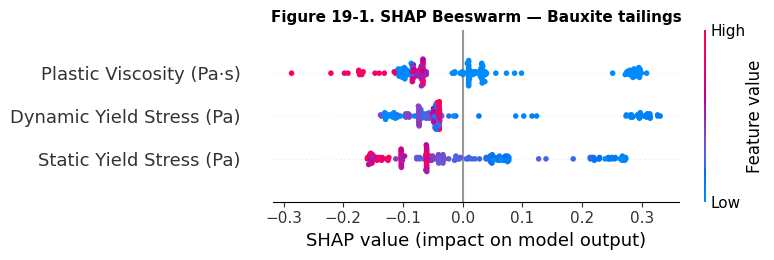

Saved: fig19_1_shap_Bauxite_tail.png


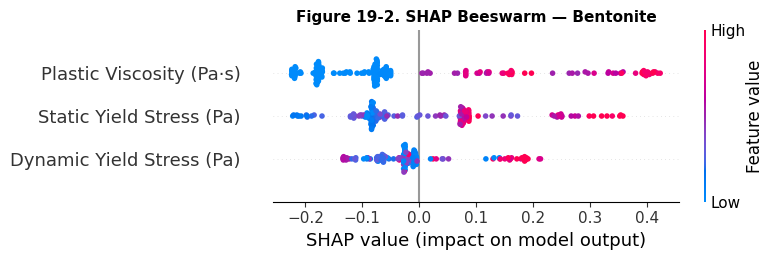

Saved: fig19_2_shap_Bentonite.png


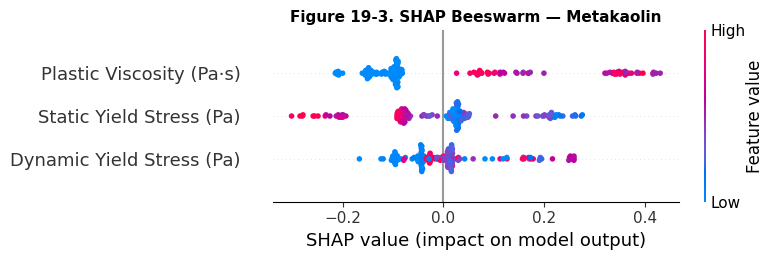

Saved: fig19_3_shap_Metakaolin.png


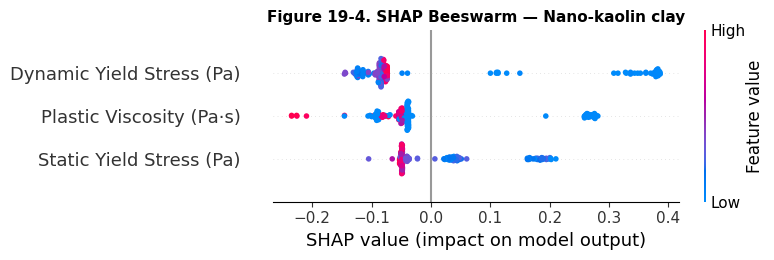

Saved: fig19_4_shap_Nano-kaolin_.png


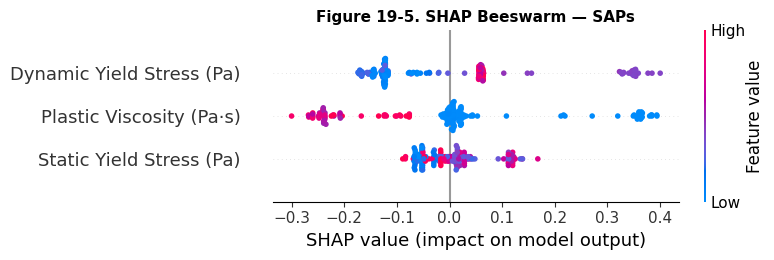

Saved: fig19_5_shap_SAPs.png


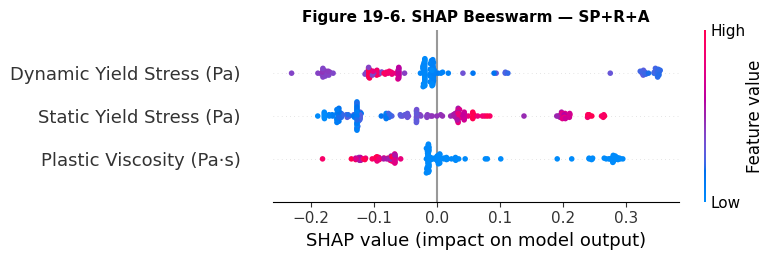

Saved: fig19_6_shap_SP+R+A.png


In [ ]:
print("\n" + "="*65)
print("SECTION 15 — SHAP VALUES")
print("="*65)

try:
    import shap
    import numpy as np
    import matplotlib.pyplot as plt

    rf_shap = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_shap.fit(X_scaled, y)
    explainer = shap.TreeExplainer(rf_shap)
    shap_values = explainer.shap_values(X_scaled)

    # Determine the structure of shap_values and adapt calculations and plotting
    if isinstance(shap_values, list):
        # Standard multi-class output: list of arrays, each (n_samples, n_features)
        print("SHAP values: list of arrays (standard multiclass format)")
        # Calculate mean absolute SHAP per feature, averaged across all classes
        mean_abs_shap_per_feature = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        shap_plot_data_per_class = shap_values
        num_shap_outputs = len(shap_values) # Should be N_CLS
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3 and shap_values.shape[2] == len(CLASSES):
        # Alternative output: single 3D array (n_samples, n_features, n_classes)
        print(f"SHAP values: single 3D array (shape {shap_values.shape})")
        # Calculate mean absolute SHAP per feature, averaged across samples and classes
        mean_abs_shap_per_feature = np.abs(shap_values).mean(axis=(0, 2))
        # For class-specific plots, we need to slice for each class
        shap_plot_data_per_class = [shap_values[:, :, i] for i in range(len(CLASSES))]
        num_shap_outputs = shap_values.shape[2]
    else:
        # Fallback for unexpected shap_values structure
        raise ValueError(f"Unexpected SHAP values structure: {type(shap_values)} with shape {getattr(shap_values, 'shape', 'N/A')}")

    # Bar chart for overall feature importance (using mean_abs_shap_per_feature)
    print("\nMean |SHAP| per feature (averaged across all classes):")
    for fl, v in zip(FEAT_LABELS, mean_abs_shap_per_feature):
        print(f"  {fl:<35}: {v:.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    si = np.argsort(mean_abs_shap_per_feature)
    ax.barh([FEAT_LABELS[i] for i in si],
             [mean_abs_shap_per_feature[i] for i in si],
             color=["#8e44ad","#3498db","#e74c3c"][::-1],
             edgecolor="black", linewidth=0.6)
    ax.set_xlabel("Mean |SHAP value| (averaged across all classes)", fontsize=11)
    ax.set_title("Figure 18. SHAP Mean Feature Importance (RF, full dataset)",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("fig18_shap_bar.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved: fig18_shap_bar.png")

    # Beeswarm plot per class (using shap_plot_data_per_class)
    for ci, cls in enumerate(CLASSES):
        if ci < num_shap_outputs: # Ensure we don't go out of bounds
            fig, _ = plt.subplots(figsize=(8, 4))
            shap.summary_plot(shap_plot_data_per_class[ci], X_scaled,
                              feature_names=FEAT_LABELS,
                              plot_type="dot", show=False)
            plt.title(f"Figure 19-{ci+1}. SHAP Beeswarm — {cls}",
                      fontsize=11, fontweight="bold")
            plt.tight_layout()
            fname = f"fig19_{ci+1}_shap_{cls[:12].replace(' ','_')}.png"
            plt.savefig(fname, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"Saved: {fname}")
        else:
            print(f"Warning: Skipping SHAP Beeswarm for class {cls} (index {ci}) due to insufficient SHAP output data.")

except ImportError:
    print("shap not installed. Run:  !pip install shap  then re-run this section.")
except Exception as e:
    print(f"SHAP error: {e}")

### Re-zipping all figures and tables, including SHAP plots

In [ ]:
import zipfile
from IPython.display import FileLink
import os

# List of generated figure files
figure_files = [
    "fig01_class_distribution.png", "fig02_boxplots.png", "fig03_violins.png",
    "fig04_stripplots.png", "fig05_pairscatter.png", "fig06_correlations.png",
    "fig07_pca_scatter.png", "fig08_anova_fstats.png", "fig09_confusion_matrices.png",
    "fig10_performance_comparison.png", "fig11_roc_curves.png", "fig12_feature_importance.png",
    "fig13_ablation.png", "fig14_learning_curves.png", "fig15_decision_tree.png",
    "fig16_decision_boundaries.png", "fig17_gridsearch_rf.png",
    # SHAP figures might not be generated if SHAP is not installed or if there's an error
    # so we will check for their existence before adding them
    "fig18_shap_bar.png",
    # Corrected filenames for Bauxite tailings and Nano-kaolin clay
    "fig19_1_shap_Bauxite_tail.png", "fig19_2_shap_Bentonite.png", "fig19_3_shap_Metakaolin.png",
    "fig19_4_shap_Nano-kaolin_.png", "fig19_5_shap_SAPs.png", "fig19_6_shap_SP+R+A.png"
]

# List of generated table files
table_files = [
    "table01_descriptive_stats.csv", "table02_pearson_correlation.csv",
    "table03_spearman_correlation.csv", "table04_anova_kruskal.csv",
    "table05_mannwhitney.csv", "table06_feature_importance.csv",
    "table07_ablation.csv", "table08_roc_auc.csv", "table09_performance_summary.csv"
]

output_zip_name = "3DPC_Rheology_Analysis_Outputs.zip"

with zipfile.ZipFile(output_zip_name, 'w') as zf:
    for file_list in [figure_files, table_files]:
        for filename in file_list:
            if os.path.exists(filename):
                zf.write(filename)
            else:
                print(f"Warning: {filename} not found, skipping.")

print(f"All available figures and tables have been zipped into {output_zip_name}")
display(FileLink(output_zip_name))

All available figures and tables have been zipped into 3DPC_Rheology_Analysis_Outputs.zip


/content/3DPC_Rheology_Analysis_Outputs.zip

In [ ]:
from google.colab import files

# Ensure the zip file name is consistent
output_zip_name = "3DPC_Rheology_Analysis_Outputs.zip"

# Initiate download
files.download(output_zip_name)

### Download all figures and tables

In [ ]:
import zipfile
from IPython.display import FileLink

# List of generated figure files
figure_files = [
    "fig01_class_distribution.png", "fig02_boxplots.png", "fig03_violins.png",
    "fig04_stripplots.png", "fig05_pairscatter.png", "fig06_correlations.png",
    "fig07_pca_scatter.png", "fig08_anova_fstats.png", "fig09_confusion_matrices.png",
    "fig10_performance_comparison.png", "fig11_roc_curves.png", "fig12_feature_importance.png",
    "fig13_ablation.png", "fig14_learning_curves.png", "fig15_decision_tree.png",
    "fig16_decision_boundaries.png", "fig17_gridsearch_rf.png",
    # SHAP figures might not be generated if SHAP is not installed or if there's an error
    # so we will check for their existence before adding them
    "fig18_shap_bar.png",
    "fig19_1_shap_Bauxite_ta.png", "fig19_2_shap_Bentonite.png", "fig19_3_shap_Metakaolin.png",
    "fig19_4_shap_Nano-kaoli.png", "fig19_5_shap_SAPs.png", "fig19_6_shap_SP+R+A.png"
]

# List of generated table files
table_files = [
    "table01_descriptive_stats.csv", "table02_pearson_correlation.csv",
    "table03_spearman_correlation.csv", "table04_anova_kruskal.csv",
    "table05_mannwhitney.csv", "table06_feature_importance.csv",
    "table07_ablation.csv", "table08_roc_auc.csv", "table09_performance_summary.csv"
]

output_zip_name = "3DPC_Rheology_Analysis_Outputs.zip"

with zipfile.ZipFile(output_zip_name, 'w') as zf:
    for file_list in [figure_files, table_files]:
        for filename in file_list:
            if os.path.exists(filename):
                zf.write(filename)
            else:
                print(f"Warning: {filename} not found, skipping.")

print(f"All available figures and tables have been zipped into {output_zip_name}")
display(FileLink(output_zip_name))

All available figures and tables have been zipped into 3DPC_Rheology_Analysis_Outputs.zip


/content/3DPC_Rheology_Analysis_Outputs.zip

In [12]:
from google.colab import files

# Ensure the zip file name is consistent
output_zip_name = "3DPC_Rheology_Analysis_Outputs.zip"

# Initiate download
files.download(output_zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>